# imports

In [4]:
import os
import pandas as pd
import numpy as np
from scipy.io import readsav
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import math
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
from mpl_toolkits.mplot3d import Axes3D
import shap
from sklearn.cluster import KMeans
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.mixture import BayesianGaussianMixture
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold


# sklearn using April21 and alldata_updated2019



In [5]:
# 1. Setup the Path
# Using a raw string to avoid escape character issues on macOS/Windows
path = r'/Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV'

if os.path.exists(path):
    print(f"✅ File found at: {path}")
    # 2. Actually load the data (This was missing in your snippet)
    # verbose=False keeps the console clean
    data = readsav(path, verbose=False)
else:
    print(f"❌ File NOT found. Current Working Directory: {os.getcwd()}")
    data = {}



✅ File found at: /Users/aldensantoso/Documents/plasma_research/ML Project/APRIL21.SAV


In [6]:

# Access the structured array
mp_struct = data['mp'][0]

# Create a dictionary where key = variable name, value = the data array
# This forces Pandas to see each IDL field as a column
mp_dict = {name: mp_struct[name] for name in mp_struct.dtype.names}

# Convert to DataFrame
mp_df = pd.DataFrame(mp_dict)

# Print the names of all 35 columns and the head
print("Column Names:", mp_df.columns.tolist())
print("-" * 30)
print(mp_df.head().T)

Column Names: ['AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN', 'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'BPTE', 'BPTI', 'BZXR', 'DIFB', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 'MNEUT', 'NES', 'NEUTT', 'NUMCHI', 'NUMNZ', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PFIRST', 'PSHINE', 'PTRANSP', 'TE', 'TOTPWR', 'TOTPWRLF', 'TOTPWRNZ', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C']
------------------------------
                        0             1             2             3  \
AVGMODEF     5.184404e+02  5.199874e+02  5.248618e+02  5.322974e+02   
AVGMODEF2    2.959607e+05  2.967030e+05  3.054608e+05  3.166740e+05   
AVGMODEF2NZ  8.397948e+05  3.359354e+05  8.741190e+05  8.765429e+05   
AVGMODEFNZ   8.914297e+02  5.781875e+02  9.312672e+02  9.352308e+02   
AVGMODEN    -6.844162e-03 -4.481572e-03 -6.299203e-02 -1.238430e-01   
AVGMODEN2    4.102969e-02  3.620911e-02  2.298250e-01  4.015467e-01   
AVGMODEN2NZ  2.362031e+01  6.456091e+01  1.190415e+01  1.000374e+01   
AVGMODENNZ

In [7]:
mp_struct = data['tr'][0]

# Create a dictionary where key = variable name, value = the data array
# This forces Pandas to see each IDL field as a column
mp_dict = {name: mp_struct[name] for name in mp_struct.dtype.names}

# Convert to DataFrame
mp_df = pd.DataFrame(mp_dict)

# Print the names of all 35 columns and the head
print("Column Names:", mp_df.columns.tolist())
print("-" * 30)
print(mp_df.head().T)

Column Names: ['BBNTS', 'BPTE', 'BPTI', 'BZXR', 'CONDE', 'DIFB', 'ETAU', 'MNEUT', 'NES', 'NEUTT', 'NEVOL', 'PFIRST', 'PSHINE', 'PTRANSP', 'PVOL', 'RAXIS', 'TE', 'TEVOL', 'TEX', 'THTAU', 'TOTAU', 'UE0', 'UEVOL', 'XCONDE']
------------------------------
                    0             1             2             3             4
BBNTS    3.747323e+12  3.547957e+12  3.441947e+12  3.132889e+12  2.995309e+12
BPTE     9.669171e+05  9.686361e+05  9.681776e+05  9.604038e+05  9.755598e+05
BPTI     6.500678e+05  6.834133e+05  6.751068e+05  6.745506e+05  6.763915e+05
BZXR     4.050812e+01  4.050787e+01  4.050712e+01  4.050520e+01  4.050877e+01
CONDE    8.422444e+05  6.692464e+05  2.304818e+05  1.410898e+05  1.744742e+05
DIFB     0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
ETAU     9.941942e-02  1.062540e-01  1.157861e-01  1.313723e-01  1.022279e-01
MNEUT    1.168565e+14  1.185199e+14  1.153493e+14  1.123694e+14  1.081185e+14
NES      6.056899e+13  6.549727e+13  6.932693e

In [8]:
# 1. Path Management
# Tip: Use the 'Copy Relative Path' feature in VS Code's sidebar for the local_path
local_path = r'data downloaded from ncrocker/APRIL21.SAV'

if not os.path.exists(local_path):
    local_path = r'/Users/aldensantoso/Desktop/OMFIT/data downloaded from ncrocker/APRIL21.SAV'

# Load with python_dict=True to make it easier to work with keys
data = readsav(local_path, python_dict=True)

def clean_idl_var(arr):
    # 1. Ensure it is a numpy array
    arr = np.asanyarray(arr)
    
    # 2. Fix the Byte Order (Endianness)
    # Modern Way: Apply newbyteorder to the dtype, then view the array with it
    # This handles the Big-Endian data typical of IDL .SAV files
    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.byteswap().view(arr.dtype.newbyteorder('='))
    
    # 3. Flatten and convert to float64
    # We use .astype(float) which is safer for numeric analysis
    return arr.flatten().astype(np.float64)

# 3. Extraction
# Accessing the first element [0] because IDL structures often load as 1-element arrays
mp_data = data['mp'][0]
tr_data = data['tr'][0]

df = pd.DataFrame({
    'avgmodef': clean_idl_var(mp_data['AVGMODEF']),
    'totpwr':   clean_idl_var(mp_data['TOTPWR']),
    'etau':     clean_idl_var(tr_data['ETAU'])
})

# 4. Data Filtering
# Removing non-physical negative values for energy confinement time
df_clean = df[df['etau'] > 0].copy()

X = df_clean[['avgmodef', 'totpwr']].values
y = df_clean['etau'].values

# 5. Pipeline
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 6. Random Forest Configuration
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 7. Evaluation
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

# 8. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='RF Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Identity Line')
plt.xlabel(r'Measured $\tau_E$')
plt.ylabel(r'Predicted $\tau_E$')
plt.title('Random Forest Regression: Confinement Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/aldensantoso/Desktop/OMFIT/data downloaded from ncrocker/APRIL21.SAV'

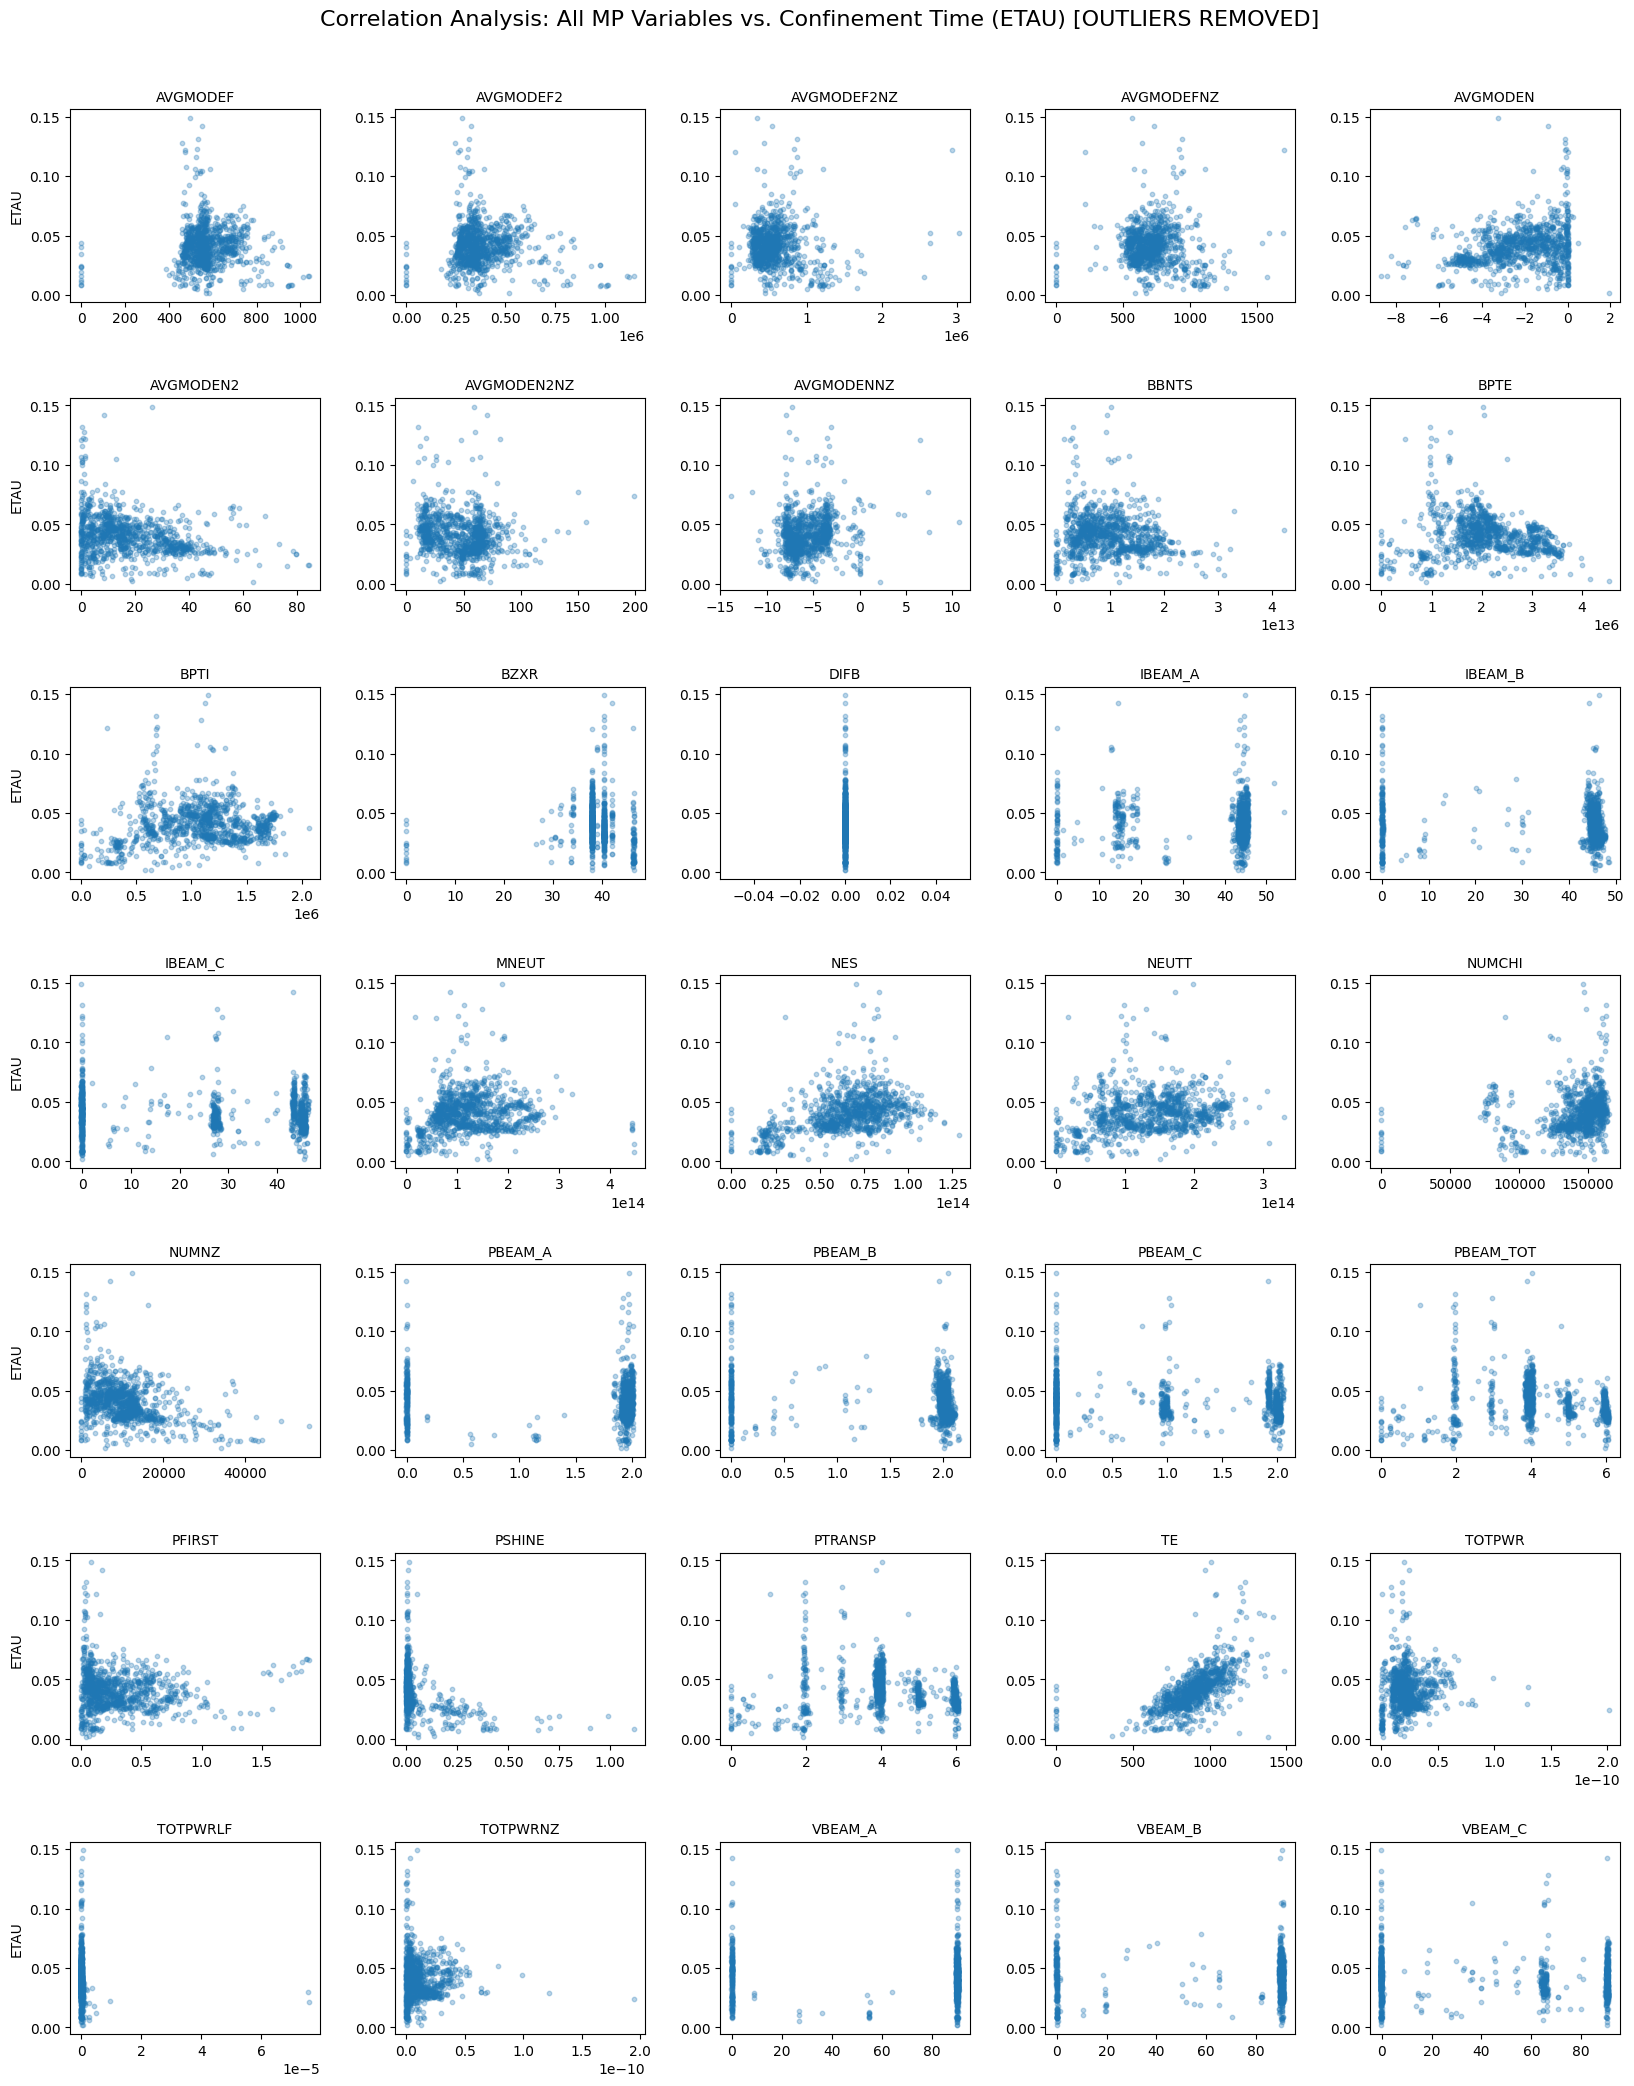

In [ ]:
# 1. Prepare data structures
mp_struct = data['mp'][0]
tr_struct = data['tr'][0]

# Clean and define the target
etau_full = clean_idl_var(tr_struct['ETAU'])
var_names = mp_struct.dtype.names

# Create a mask to remove non-positive confinement times
mask = etau_full > 0
etau_clean = etau_full[mask]

# 2. Setup plotting grid (7 rows x 5 columns for 35 variables)
rows = 7
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(20, 25))
fig.subplots_adjust(hspace=0.5, wspace=0.3)

# 3. Iterate and plot
for i, name in enumerate(var_names):
    ax = axes[i // cols, i % cols]
    # Clean the variable data and apply the same mask
    x_data_full = clean_idl_var(mp_struct[name])
    x_data_clean = x_data_full[mask]

    # Plot against etau
    ax.scatter(x_data_clean, etau_clean, alpha=0.3, s=10)
    ax.set_title(name, fontsize=10)
    if i % cols == 0:
        ax.set_ylabel('ETAU')

plt.suptitle('Correlation Analysis: All MP Variables vs. Confinement Time (ETAU) [OUTLIERS REMOVED]', fontsize=16, y=0.92)
plt.show()

In [ ]:

data = readsav(path, python_dict=True)
mp_data = data['mp'][0]
tr_data = data['tr'][0]

y_raw = clean_idl_var(tr_data['ETAU'])
y_clean = y_raw[y_raw > 0]
# Diagnostic check to find the outlier
print(f"Original y_raw min: {y_raw.min()}")
print(f"Cleaned y_clean min: {y_clean.min()}")

# Find the index and value of the most extreme outlier in y_raw
outlier_idx = np.argmin(y_raw)
print(f"Value at most negative index ({outlier_idx}): {y_raw[outlier_idx]}")

# Check if any values <= 0 still exist in y_clean
le_zero = y_clean[y_clean <= 0]
print(f"Values <= 0 in y_clean: {le_zero}")

# Also check the values used in the correlation plots specifically
etau_clean_min = etau_clean.min()
print(f"ETAU values used in plots min: {etau_clean_min}")

Original y_raw min: -3.116468667984009
Cleaned y_clean min: 0.0017872649477794766
Value at most negative index (993): -3.116468667984009
Values <= 0 in y_clean: []
ETAU values used in plots min: 0.0017872649477794766


In [ ]:
# 1. Load the Data
# Assuming 'data' is the dictionary returned by readsav('/content/drive/MyDrive/OMFIT/APRIL21.SAV')
data = readsav('/content/drive/MyDrive/OMFIT/APRIL21.SAV', python_dict=True)

# 2. Extract and Reshape Variables
# Note: IDL variables are often loaded as 1D arrays inside the dict.
# We use .flatten() to ensure they are 1D for column_stack.

# Access the 'mp' and 'tr' structured arrays
mp_data_struct = data['mp'][0]
tr_data_struct = data['tr'][0]

avg_mode_f = mp_data_struct['AVGMODEF'].flatten()
tot_pwr = mp_data_struct['TOTPWR'].flatten()
etau = tr_data_struct['ETAU'].flatten()

# 3. Align Features and Target
X_raw = np.column_stack((avg_mode_f, tot_pwr))
y_raw = etau

# 4. Basic Cleaning: Remove unphysical outliers (e.g., negative confinement)
mask = y_raw > 0  # Changed to > 0 as confinement time shouldn't be zero/negative
X_clean = X_raw[mask]
y_clean = y_raw[mask]

# 5. Scaling
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_clean)

# 6. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_clean, test_size=0.2, random_state=42
)

# 7. Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 8. Predict and Evaluate
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

# 9. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predictions')

# Reference line for perfect fit
line_range = np.array([y_test.min(), y_test.max()])
plt.plot(line_range, line_range, 'r--', lw=2, label='Perfect Fit')

# Set y-axis bounds (adjust as needed)
plt.ylim(0, y_test.max() * 1.1)

plt.xlabel(r'Measured Confinement Time ($\tau_E$)')
plt.ylabel(r'Predicted Confinement Time ($\tau_E$)')
plt.title('ML Model Performance: Mode Params vs. $\tau_E$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/OMFIT/APRIL21.SAV'

Log-scale R2 Score: 0.7114
Mean Absolute Error: 0.005125 s


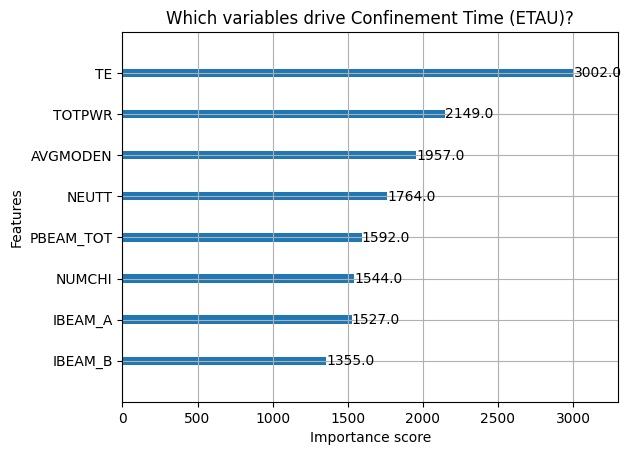

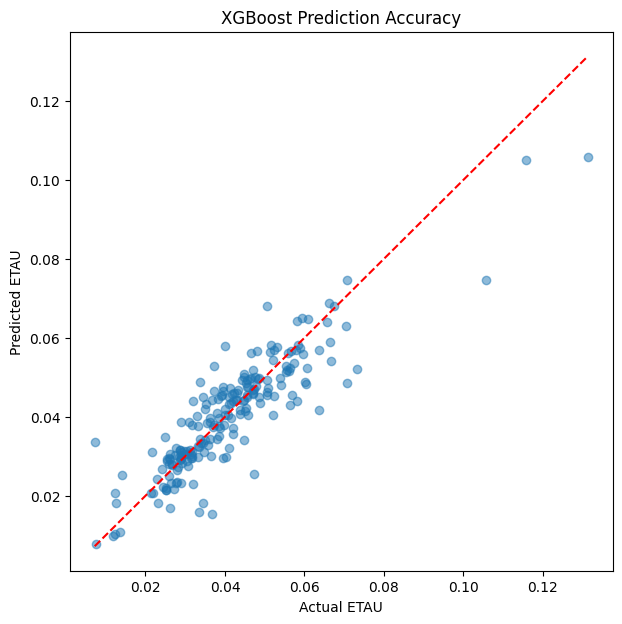

In [ ]:
# 1. Extraction: We need to pull all requested features from the raw data
mp_struct = data['mp'][0]
tr_struct = data['tr'][0]

# List of variables to extract
feature_names = ['TE', 'TOTPWR', 'AVGMODEN', 'NEUTT', 'PBEAM_TOT', 'IBEAM_A', 'IBEAM_B', 'NUMCHI']
target_name = 'ETAU'

# Build dictionary of cleaned arrays
data_dict = {}
for name in feature_names:
    data_dict[name] = clean_idl_var(mp_struct[name])
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

# Create the full DataFrame
df_full = pd.DataFrame(data_dict)

# 2. Filter outliers (same as before)
df_clean = df_full[df_full[target_name] > 0].copy()

# 3. Preprocessing: Log-Transform
X = df_clean[feature_names].copy()
y = np.log10(df_clean[target_name])

# Log-transform continuous features (adding small epsilon to avoid log(0))
for col in ['TE', 'TOTPWR', 'AVGMODEN', 'NEUTT']:
    X[col] = np.log10(X[col].abs() + 1e-12)

# 4. Split the data (Fixed typo from test_test_split to test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and Train XGBoost Regressor
model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

model_xgb.fit(X_train, y_train)

# 6. Predictions and Evaluation
y_pred_log = model_xgb.predict(X_test)
y_pred = 10**y_pred_log
y_test_actual = 10**y_test

print(f"Log-scale R2 Score: {r2_score(y_test, y_pred_log):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test_actual, y_pred):.6f} s")

# 7. Feature Importance Plot
xgb.plot_importance(model_xgb)
plt.title("Which variables drive Confinement Time (ETAU)?")
plt.show()

# 8. Actual vs Predicted Plot
plt.figure(figsize=(7,7))
plt.scatter(y_test_actual, y_pred, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.xlabel("Actual ETAU")
plt.ylabel("Predicted ETAU")
plt.title("XGBoost Prediction Accuracy")
plt.show()

# Ibeam Clustering

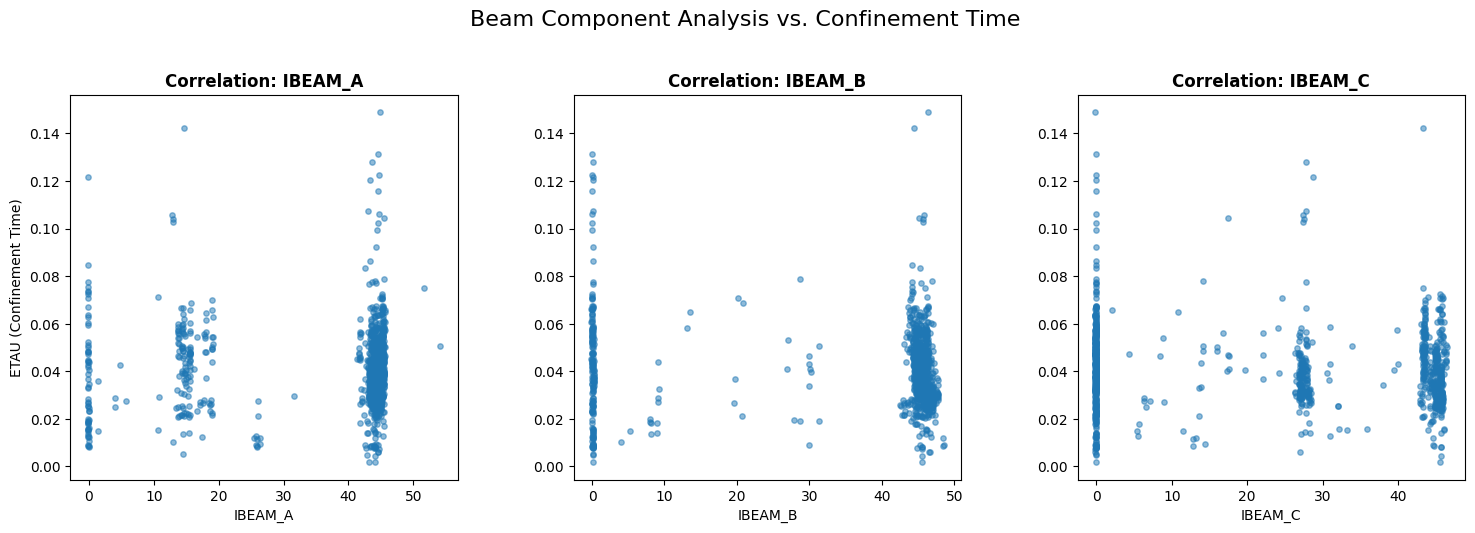

In [ ]:
# 1. Prepare data structures
mp_struct = data['mp'][0]
tr_struct = data['tr'][0]

# Clean and define the target (Confinement Time)
etau_full = clean_idl_var(tr_struct['ETAU'])
mask = etau_full > 0
etau_clean = etau_full[mask]

# --- MODIFIED SECTION: Filter for specific Ibeams ---
# We check for the names in the struct. Note: IDL tags are usually uppercase.
target_ibeams = ['IBEAM_A', 'IBEAM_B', 'IBEAM_C'] # Fixed variable names
# Ensure we only pick names that actually exist in mp_struct
selected_vars = [name for name in mp_struct.dtype.names if name.upper() in [t.upper() for t in target_ibeams]]
# ----------------------------------------------------

# 2. Setup plotting grid (1 row x 3 columns)
fig, axes = plt.subplots(1, len(selected_vars), figsize=(18, 5))
fig.subplots_adjust(wspace=0.3)

# 3. Iterate and plot only selected variables
for i, name in enumerate(selected_vars):
    ax = axes[i]

    # Clean the variable data and apply the same mask
    x_data_full = clean_idl_var(mp_struct[name])
    x_data_clean = x_data_full[mask]

    # Plot against etau
    ax.scatter(x_data_clean, etau_clean, alpha=0.5, s=15, color='tab:blue')
    ax.set_title(f'Correlation: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel(name)
    if i == 0:
        ax.set_ylabel('ETAU (Confinement Time)')

plt.suptitle('Beam Component Analysis vs. Confinement Time', fontsize=16, y=1.05)
plt.show()

/Users/aldensantoso/Library/Python/3.13/lib/python/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/aldensantoso/Library/Python/3.13/lib/python/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/Users/aldensantoso/Library/Python/3.13/lib/python/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/aldensantoso/Library/Python/3.13/lib/python/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/aldensantoso/Library/Python/3.13/lib/python/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/aldensantoso/Library/Python/3.13/lib/python/

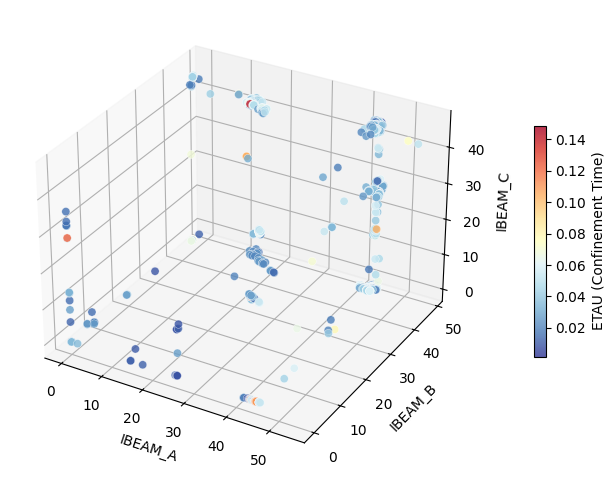

In [ ]:
# 2. Prepare Data (Using the master_mask strategy)
etau_raw = clean_idl_var(tr_struct['ETAU'])
master_mask = etau_raw > 0

# 2. Apply the mask to all 4 dimensions (A, B, C, and the Color variable)
# We clean them FIRST, then apply the mask immediately
a_clean = clean_idl_var(mp_struct['IBEAM_A'])[master_mask]
b_clean = clean_idl_var(mp_struct['IBEAM_B'])[master_mask]
c_clean = clean_idl_var(mp_struct['IBEAM_C'])[master_mask]
etau_clean = etau_raw[master_mask]

# 1. Calculate derivatives (assuming 'time' is available in your struct)
time = clean_idl_var(tr_struct['ETAU'])
da_dt = np.gradient(clean_idl_var(mp_struct['IBEAM_A']), time)
db_dt = np.gradient(clean_idl_var(mp_struct['IBEAM_B']), time)
dc_dt = np.gradient(clean_idl_var(mp_struct['IBEAM_C']), time)

# 2. Define stability (e.g., change < 5% per second)
epsilon = 0.01
is_stable = (np.abs(da_dt) < epsilon) & (np.abs(db_dt) < epsilon) & (np.abs(dc_dt) < epsilon)

# 3. Update master_mask to include stability
# Now we only plot points where ETAU > 0 AND the beams aren't ramping
master_mask = (etau_raw > 0) & is_stable

# (The rest of your plotting code follows...)

# 2. Setup the interactive 3D plot
# 'fig' and 'ax' are now live objects in VS Code
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    a_clean, b_clean, c_clean,
    c=etau_clean,
    cmap='RdYlBu_r',
    alpha=0.8,
    s=35,
    edgecolors='w', # Added edgecolors to make points visible during rotation
    linewidth=0.3
)

# 3. Add labels and a clean colorbar
ax.set_xlabel('IBEAM_A')
ax.set_ylabel('IBEAM_B')
ax.set_zlabel('IBEAM_C')

# Using 'ax=ax' ensures the colorbar stays attached during rotation
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('ETAU (Confinement Time)')

plt.show()

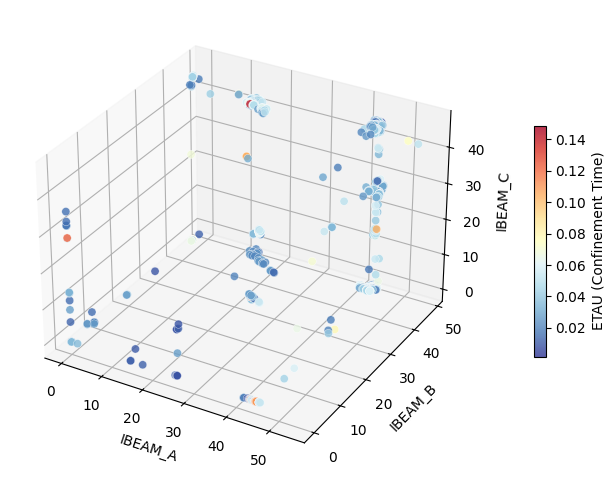

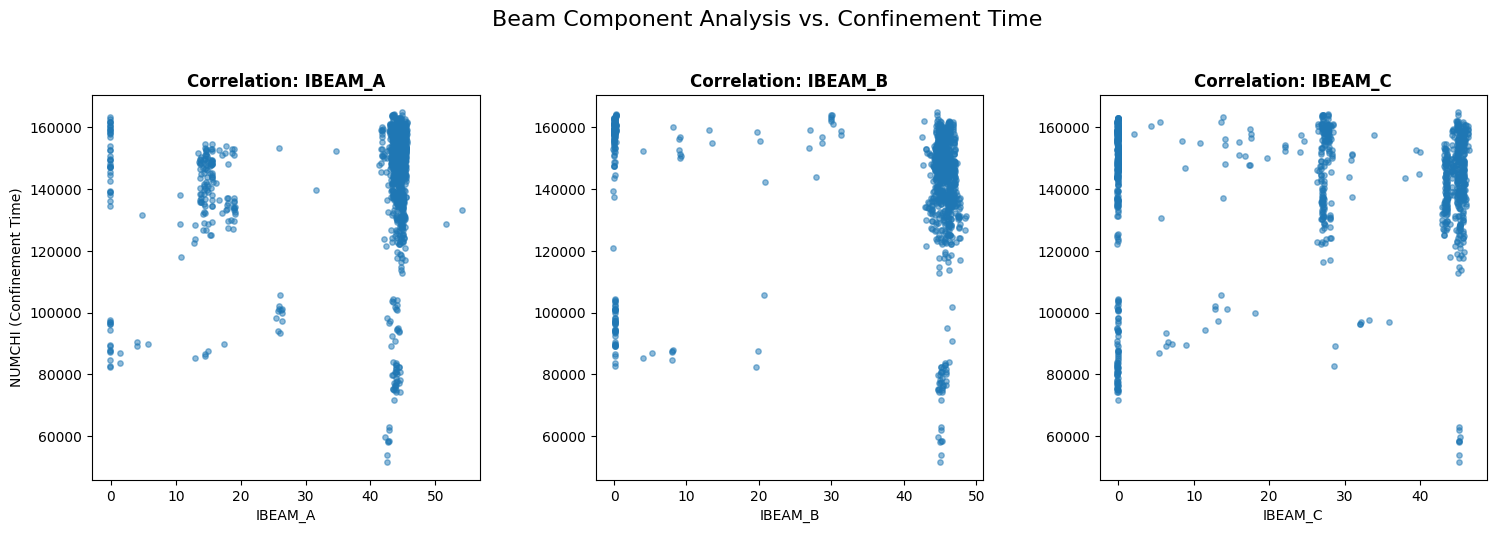

In [ ]:
# 1. Prepare data structures
mp_struct = data['mp'][0]
tr_struct = data['tr'][0]

# Clean and define the target (Confinement Time)
numchi_full = clean_idl_var(mp_struct['NUMCHI'])
mask = numchi_full > 0
numchi_clean = numchi_full[mask]

# --- MODIFIED SECTION: Filter for specific Ibeams ---
# We check for the names in the struct. Note: IDL tags are usually uppercase.
target_ibeams = ['IBEAM_A', 'IBEAM_B', 'IBEAM_C'] # Fixed variable names
# Ensure we only pick names that actually exist in mp_struct
selected_vars = [name for name in mp_struct.dtype.names if name.upper() in [t.upper() for t in target_ibeams]]
# ----------------------------------------------------
# 2. Setup plotting grid (1 row x 3 columns)
fig, axes = plt.subplots(1, len(selected_vars), figsize=(18, 5))
fig.subplots_adjust(wspace=0.3)

# 3. Iterate and plot only selected variables
for i, name in enumerate(selected_vars):
    ax = axes[i]

    # Clean the variable data and apply the same mask
    x_data_full = clean_idl_var(mp_struct[name])
    x_data_clean = x_data_full[mask]

    # Plot against numchi
    ax.scatter(x_data_clean, numchi_clean, alpha=0.5, s=15, color='tab:blue')
    ax.set_title(f'Correlation: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel(name)
    if i == 0:
        ax.set_ylabel('NUMCHI (Confinement Time)')

plt.suptitle('Beam Component Analysis vs. Confinement Time', fontsize=16, y=1.05)
plt.show()

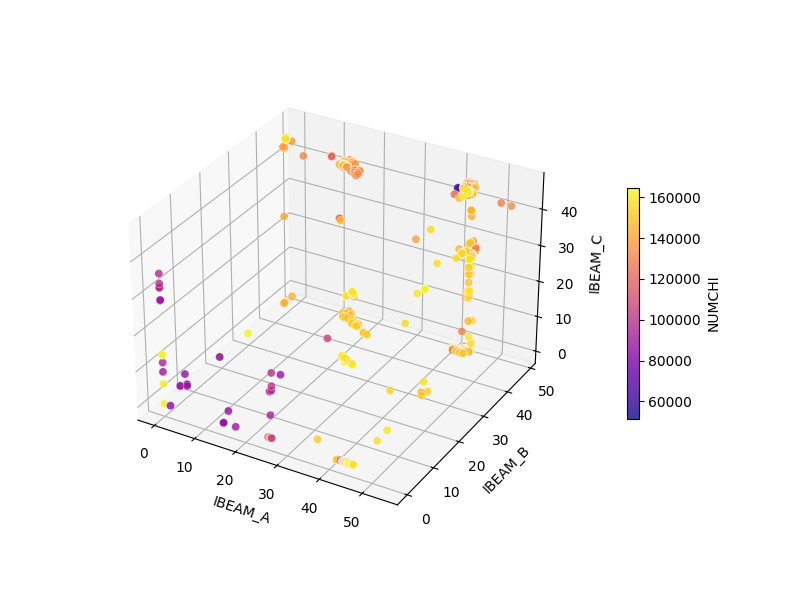

In [ ]:
# 2. Prepare Data (Using the master_mask strategy)
numchi_raw = clean_idl_var(mp_struct['NUMCHI'])
master_mask = numchi_raw > 0

# 2. Apply the mask to all 4 dimensions (A, B, C, and the Color variable)
# We clean them FIRST, then apply the mask immediately
a_clean = clean_idl_var(mp_struct['IBEAM_A'])[master_mask]
b_clean = clean_idl_var(mp_struct['IBEAM_B'])[master_mask]
c_clean = clean_idl_var(mp_struct['IBEAM_C'])[master_mask]
numchi_clean = numchi_raw[master_mask]

# ... (your data cleaning and masking code here) ...

# 2. Setup the interactive 3D plot
# 'fig' and 'ax' are now live objects in VS Code
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    a_clean, b_clean, c_clean,
    c=numchi_clean,
    cmap='plasma',
    alpha=0.8,
    s=35,
    edgecolors='w', # Added edgecolors to make points visible during rotation
    linewidth=0.3
)

# 3. Add labels and a clean colorbar
ax.set_xlabel('IBEAM_A')
ax.set_ylabel('IBEAM_B')
ax.set_zlabel('IBEAM_C')

# Using 'ax=ax' ensures the colorbar stays attached during rotation
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('NUMCHI')

plt.show()

In [ ]:
print(mp_struct.dtype.names)

('AVGMODEF', 'AVGMODEF2', 'AVGMODEF2NZ', 'AVGMODEFNZ', 'AVGMODEN', 'AVGMODEN2', 'AVGMODEN2NZ', 'AVGMODENNZ', 'BBNTS', 'BPTE', 'BPTI', 'BZXR', 'DIFB', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 'MNEUT', 'NES', 'NEUTT', 'NUMCHI', 'NUMNZ', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'PBEAM_TOT', 'PFIRST', 'PSHINE', 'PTRANSP', 'TE', 'TOTPWR', 'TOTPWRLF', 'TOTPWRNZ', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C')


# PBeam Clustering


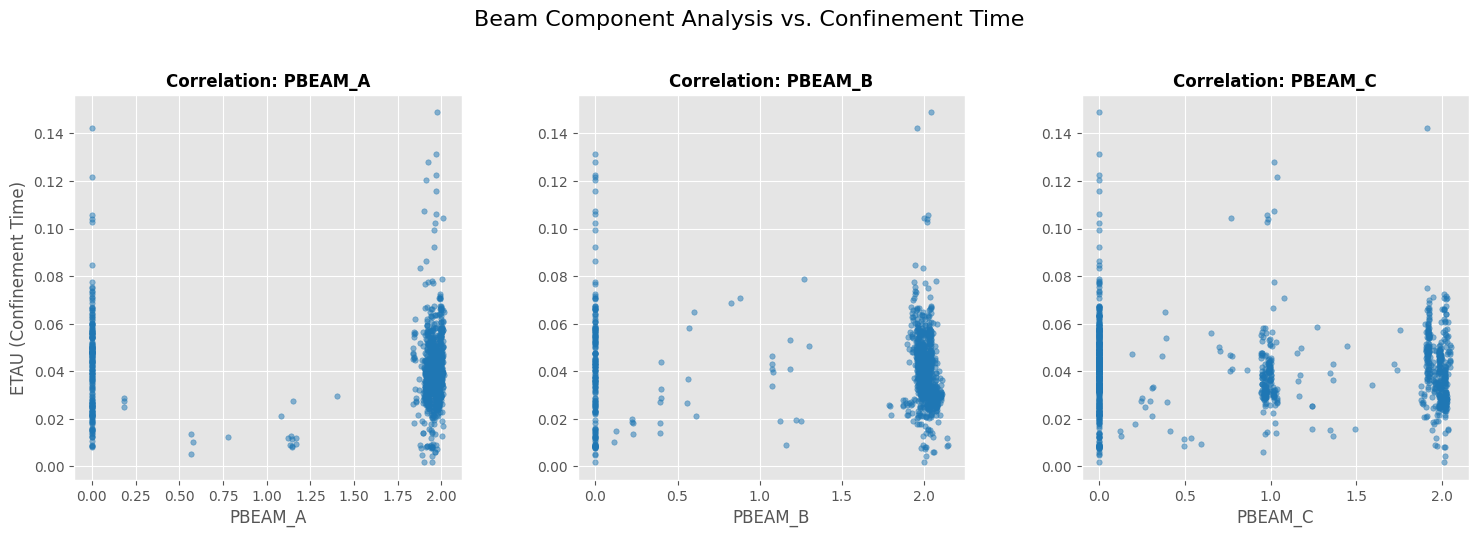

In [ ]:
# 1. Prepare data structures
mp_struct = data['mp'][0]
tr_struct = data['tr'][0]

# Clean and define the target (Confinement Time)
etau_full = clean_idl_var(tr_struct['ETAU'])
mask = etau_full > 0
etau_clean = etau_full[mask]

# --- MODIFIED SECTION: Filter for specific Ibeams ---
# We check for the names in the struct. Note: IDL tags are usually uppercase.
target_ibeams = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C'] # Fixed variable names
# Ensure we only pick names that actually exist in mp_struct
selected_vars = [name for name in mp_struct.dtype.names if name.upper() in [t.upper() for t in target_ibeams]]
# ----------------------------------------------------

# 2. Setup plotting grid (1 row x 3 columns)
fig, axes = plt.subplots(1, len(selected_vars), figsize=(18, 5))
fig.subplots_adjust(wspace=0.3)

# 3. Iterate and plot only selected variables
for i, name in enumerate(selected_vars):
    ax = axes[i]

    # Clean the variable data and apply the same mask
    x_data_full = clean_idl_var(mp_struct[name])
    x_data_clean = x_data_full[mask]

    # Plot against etau
    ax.scatter(x_data_clean, etau_clean, alpha=0.5, s=15, color='tab:blue')
    ax.set_title(f'Correlation: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel(name)
    if i == 0:
        ax.set_ylabel('ETAU (Confinement Time)')

plt.suptitle('Beam Component Analysis vs. Confinement Time', fontsize=16, y=1.05)
plt.show()

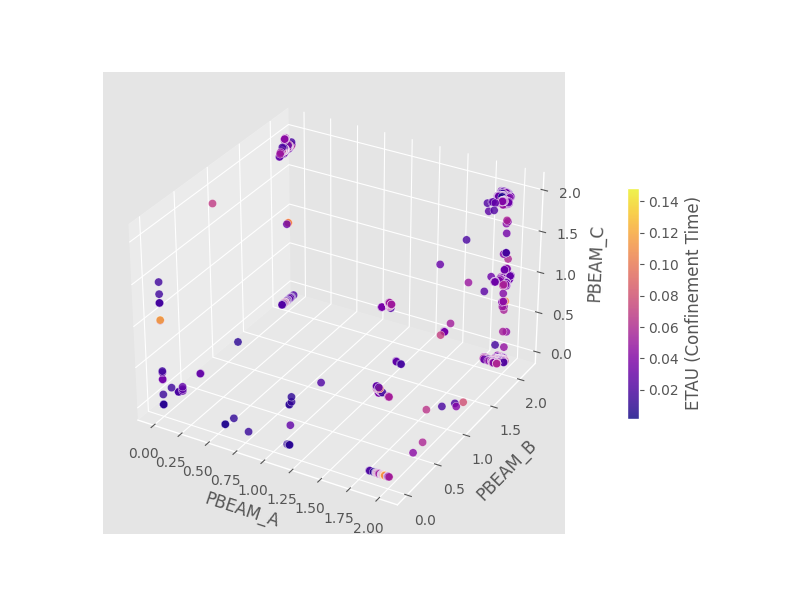

In [ ]:
# 2. Prepare Data (Using the master_mask strategy)
etau_raw = clean_idl_var(tr_struct['ETAU'])
master_mask = etau_raw > 0

# 2. Apply the mask to all 4 dimensions (A, B, C, and the Color variable)
# We clean them FIRST, then apply the mask immediately
a_clean = clean_idl_var(mp_struct['PBEAM_A'])[master_mask]
b_clean = clean_idl_var(mp_struct['PBEAM_B'])[master_mask]
c_clean = clean_idl_var(mp_struct['PBEAM_C'])[master_mask]
etau_clean = etau_raw[master_mask]

# ... (your data cleaning and masking code here) ...

# 2. Setup the interactive 3D plot
# 'fig' and 'ax' are now live objects in VS Code
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    a_clean, b_clean, c_clean,
    c=etau_clean,
    cmap='plasma',
    alpha=0.8,
    s=35,
    edgecolors='w', # Added edgecolors to make points visible during rotation
    linewidth=0.3
)

# 3. Add labels and a clean colorbar
ax.set_xlabel('PBEAM_A')
ax.set_ylabel('PBEAM_B')
ax.set_zlabel('PBEAM_C')

# Using 'ax=ax' ensures the colorbar stays attached during rotation
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('ETAU (Confinement Time)')

plt.show()

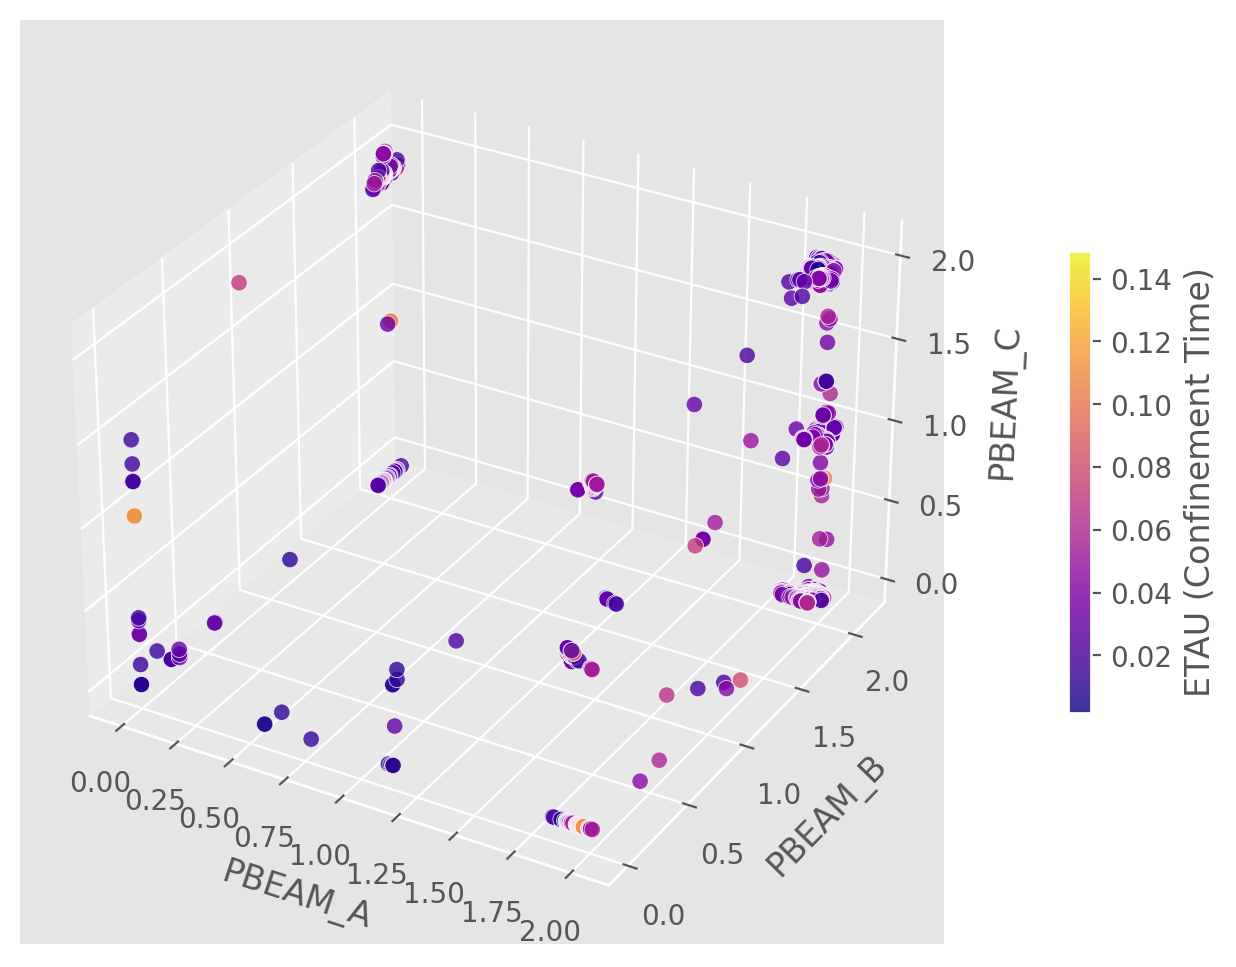

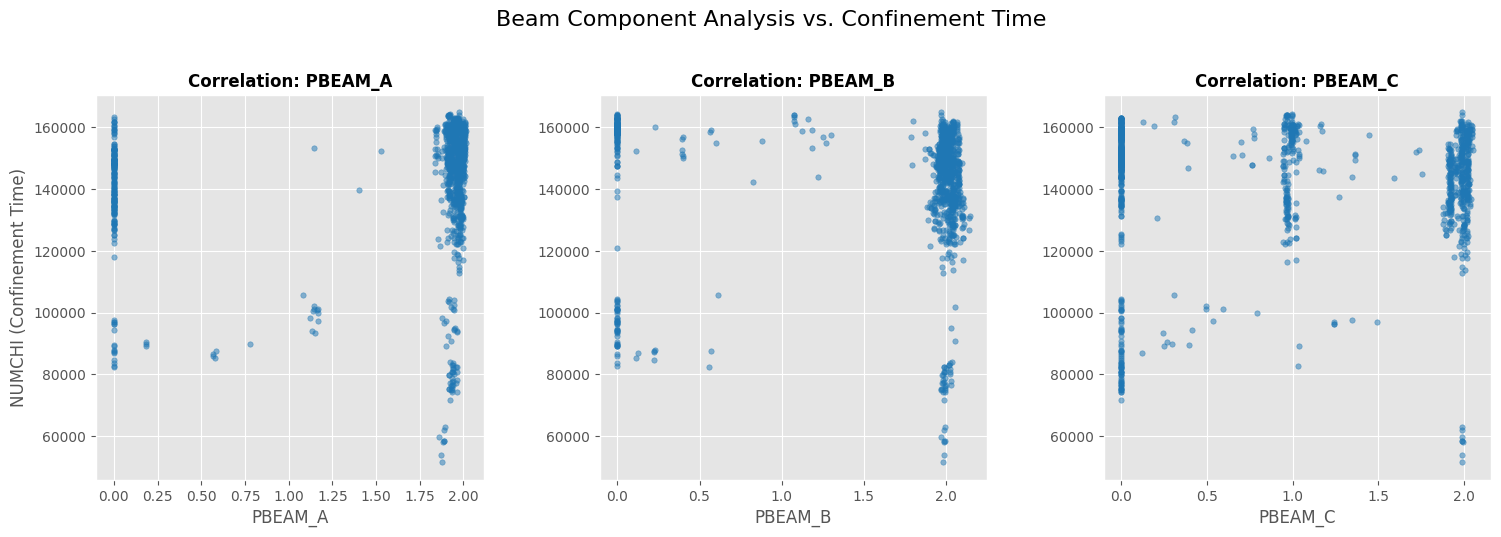

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data structures
mp_struct = data['mp'][0]
tr_struct = data['tr'][0]

# Clean and define the target (Confinement Time)
numchi_full = clean_idl_var(mp_struct['NUMCHI'])
mask = numchi_full > 0
numchi_clean = numchi_full[mask]

# --- MODIFIED SECTION: Filter for specific Ibeams ---
# We check for the names in the struct. Note: IDL tags are usually uppercase.
target_ibeams = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C'] # Fixed variable names
# Ensure we only pick names that actually exist in mp_struct
selected_vars = [name for name in mp_struct.dtype.names if name.upper() in [t.upper() for t in target_ibeams]]
# ----------------------------------------------------
# 2. Setup plotting grid (1 row x 3 columns)
fig, axes = plt.subplots(1, len(selected_vars), figsize=(18, 5))
fig.subplots_adjust(wspace=0.3)

# 3. Iterate and plot only selected variables
for i, name in enumerate(selected_vars):
    ax = axes[i]

    # Clean the variable data and apply the same mask
    x_data_full = clean_idl_var(mp_struct[name])
    x_data_clean = x_data_full[mask]

    # Plot against numchi
    ax.scatter(x_data_clean, numchi_clean, alpha=0.5, s=15, color='tab:blue')
    ax.set_title(f'Correlation: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel(name)
    if i == 0:
        ax.set_ylabel('NUMCHI (Confinement Time)')

plt.suptitle('Beam Component Analysis vs. Confinement Time', fontsize=16, y=1.05)
plt.show()

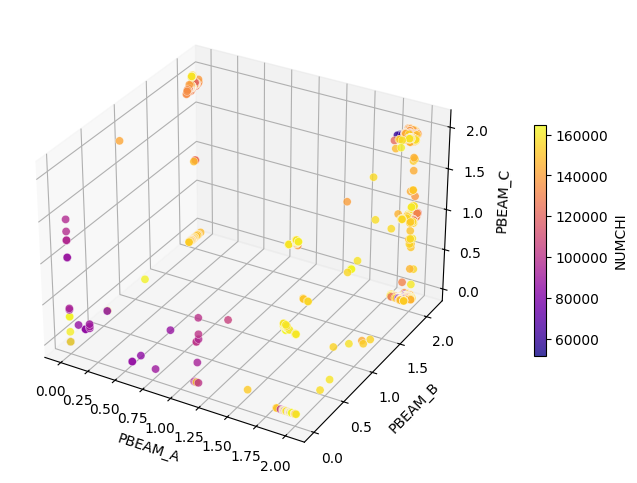

In [ ]:
# 2. Prepare Data (Using the master_mask strategy)
numchi_raw = clean_idl_var(mp_struct['NUMCHI'])
master_mask = numchi_raw > 0

# 2. Apply the mask to all 4 dimensions (A, B, C, and the Color variable)
# We clean them FIRST, then apply the mask immediately
a_clean = clean_idl_var(mp_struct['PBEAM_A'])[master_mask]
b_clean = clean_idl_var(mp_struct['PBEAM_B'])[master_mask]
c_clean = clean_idl_var(mp_struct['PBEAM_C'])[master_mask]
numchi_clean = numchi_raw[master_mask]

# ... (your data cleaning and masking code here) ...

# 2. Setup the interactive 3D plot
# 'fig' and 'ax' are now live objects in VS Code
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    a_clean, b_clean, c_clean,
    c=numchi_clean,
    cmap='plasma',
    alpha=0.8,
    s=35,
    edgecolors='w', # Added edgecolors to make points visible during rotation
    linewidth=0.3
)

# 3. Add labels and a clean colorbar
ax.set_xlabel('PBEAM_A')
ax.set_ylabel('PBEAM_B')
ax.set_zlabel('PBEAM_C')

# Using 'ax=ax' ensures the colorbar stays attached during rotation
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('NUMCHI')

plt.show()

In [ ]:
# Ensure we are pulling from the correct structures
# Note: Using your variable names from earlier
etau_raw = clean_idl_var(tr_struct['ETAU'])
master_mask = etau_raw > 0

features_dict = {
    'ETAU': etau_raw[master_mask],
    'TOTPWR': clean_idl_var(mp_struct['TOTPWR'])[master_mask],
    'PBEAM_A': clean_idl_var(mp_struct['PBEAM_A'])[master_mask],
    'PBEAM_B': clean_idl_var(mp_struct['PBEAM_B'])[master_mask],
    'PBEAM_C': clean_idl_var(mp_struct['PBEAM_C'])[master_mask],
    'IBEAM_A': clean_idl_var(mp_struct['IBEAM_A'])[master_mask],
    'AVGMODEN': clean_idl_var(mp_struct['AVGMODEN'])[master_mask],
    'TE': clean_idl_var(mp_struct['TE'])[master_mask],
    'NUMCHI': clean_idl_var(mp_struct['NUMCHI'])[master_mask],
    'BZXR' : clean_idl_var(mp_struct['BZXR'])[master_mask]
}

df = pd.DataFrame(features_dict)

# Filter for the 0-2 MW or 4MW range as per your logic
max_p = df['TOTPWR'].max()
p_min, p_max = (3.8e6, 4.2e6) if max_p > 1e6 else (0, 2)
df_4mw = df[(df['TOTPWR'] >= p_min) & (df['TOTPWR'] <= p_max)].copy()

# Add the clusters
beam_features = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C']
kmeans = KMeans(n_clusters=4, random_state=42)
df_4mw['Beam_Cluster'] = kmeans.fit_predict(df_4mw[beam_features])

print(f"Dataframe df_4mw created with {len(df_4mw)} rows.")

Dataframe df_4mw created with 1033 rows.


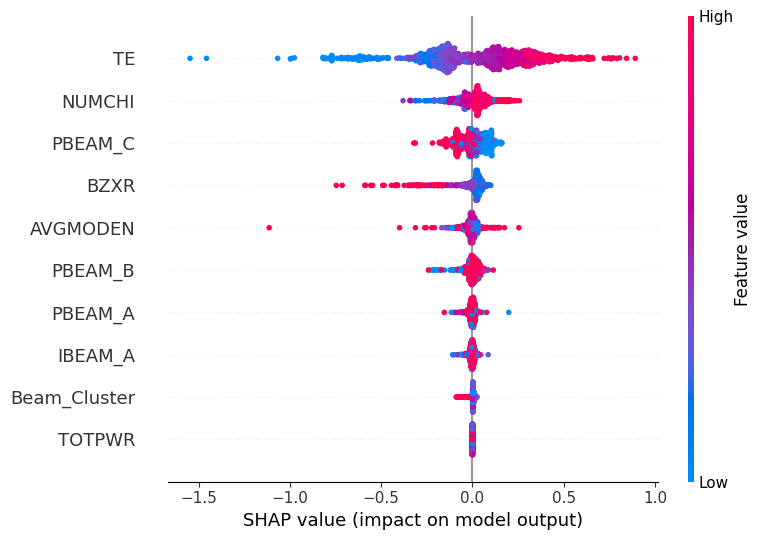

In [ ]:
# 1. Define the 8 features EXACTLY as they appear in your heatmap
physics_features = [
    'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'IBEAM_A', 
    'TOTPWR', 'AVGMODEN', 'TE', 'BZXR', 'NUMCHI', 'Beam_Cluster'
]

# 2. Prepare X and y
X = df_4mw[physics_features]
y = np.log(df_4mw['ETAU'])

# 3. Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 4. Generate SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X)

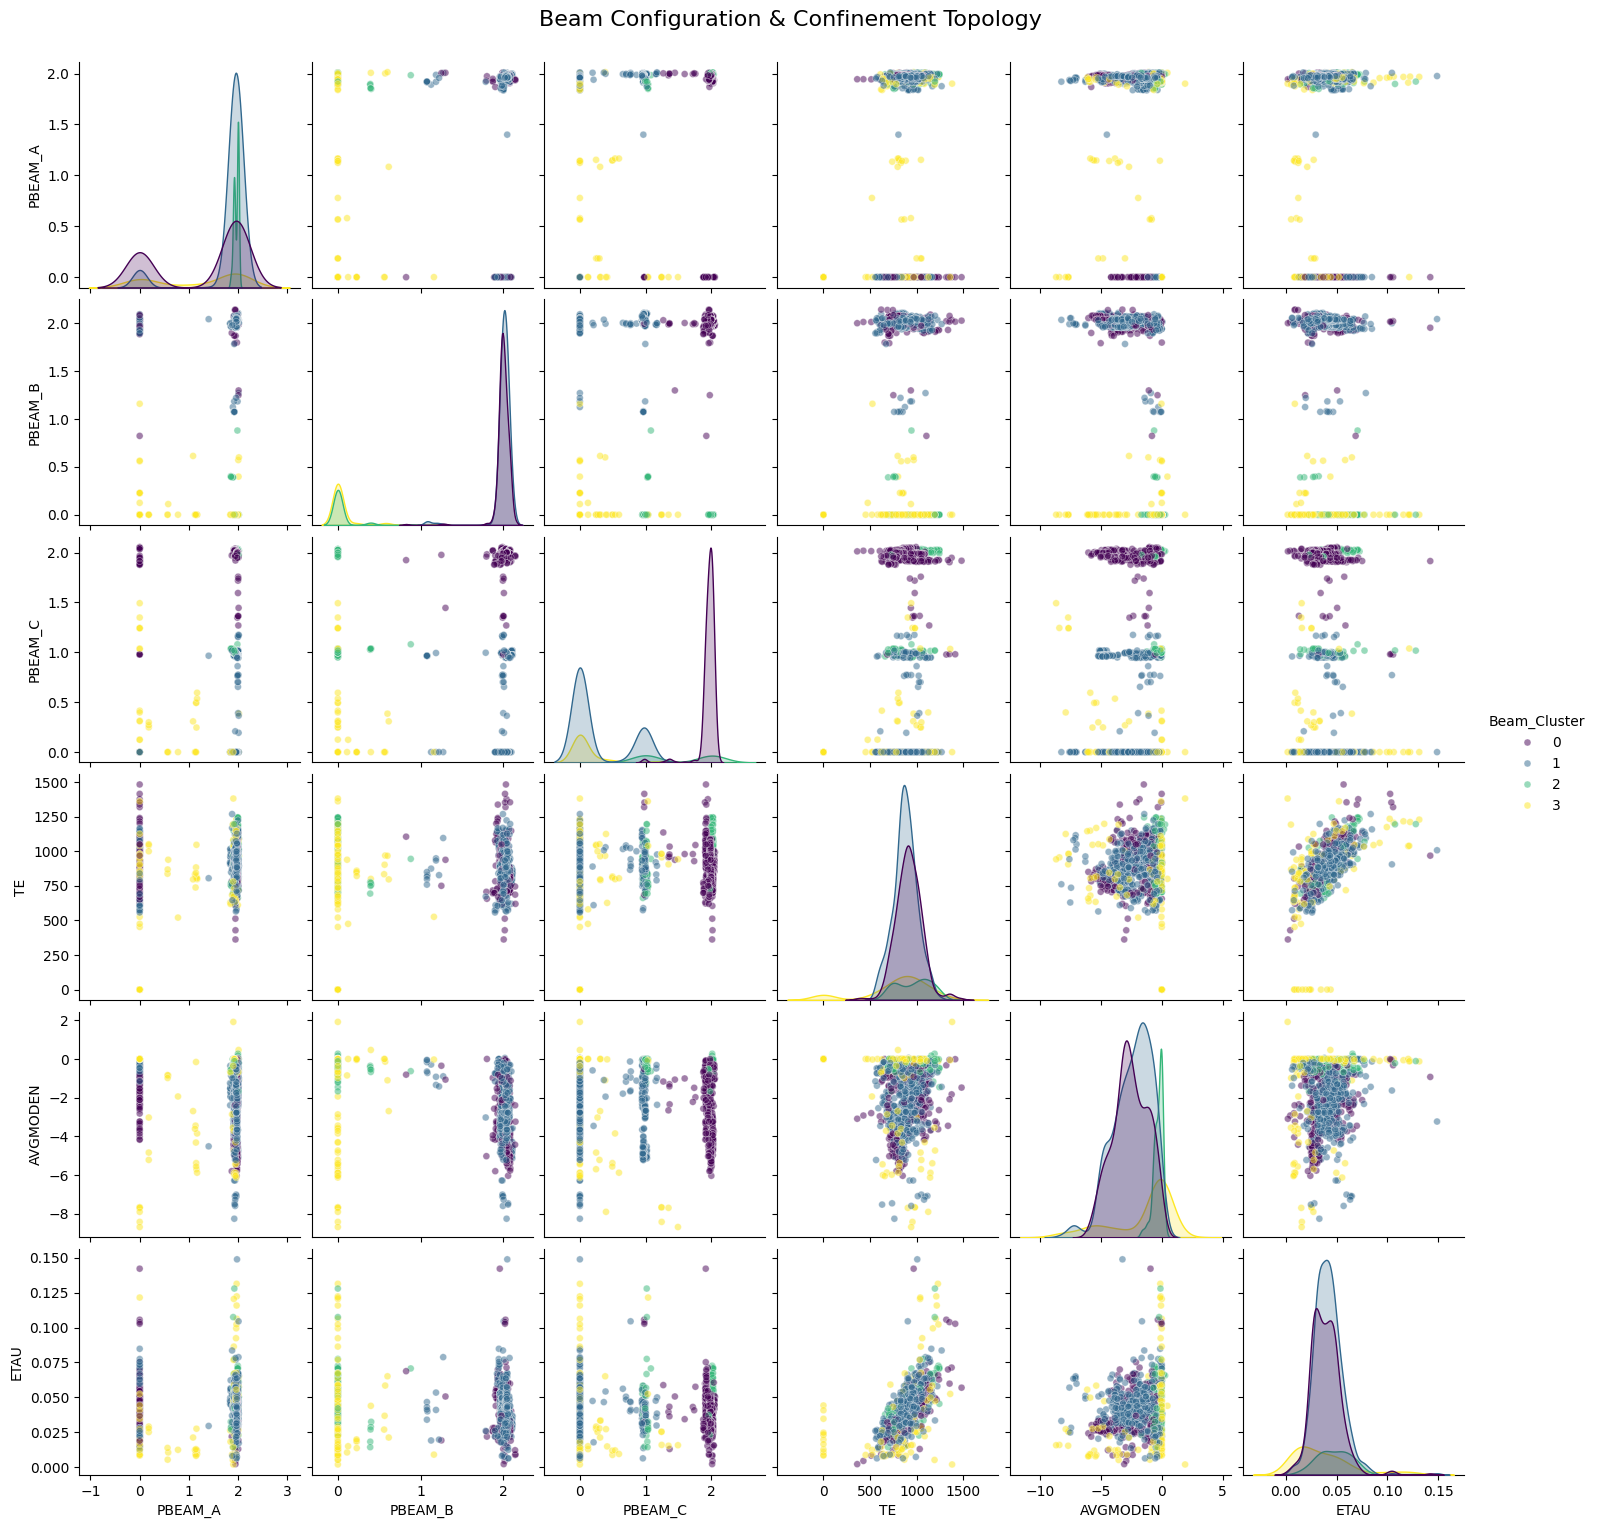

In [ ]:
# 1. Select the specific physics columns for the grid
# Including 'Beam_Cluster' is what creates the different colored humps (purple/yellow/etc.)
plot_vars = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'TE','AVGMODEN', 'ETAU']

# 2. Generate the plot
# 'hue' is the magic variable that separates the 'shit' by cluster color
# 'diag_kind' creates those smooth humps instead of histograms
g = sns.pairplot(
    df_4mw[plot_vars + ['Beam_Cluster']], 
    hue='Beam_Cluster', 
    palette='viridis', 
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 25},
    diag_kws={'fill': True}
)

# 3. Add a title and clean up
g.fig.suptitle("Beam Configuration & Confinement Topology", y=1.02, fontsize=16)
plt.show()

In [ ]:
# Check 1: The Sample Size (Row Count)
print(f"Total Shots in df_4mw: {len(df_4mw)}")

# Check 2: The Precise Averages
# If these match to the 3rd decimal place, your data is identical.
print("\n--- Physics Mean Check ---")
print(df_4mw[['PBEAM_A', 'TE', 'ETAU']].mean())

# Check 3: The Clustering 'Seed'
# Check the labels of your clusters. 
print("\n--- Cluster Counts ---")
print(df_4mw['Beam_Cluster'].value_counts())

Total Shots in df_4mw: 1033

--- Physics Mean Check ---
PBEAM_A      1.560315
TE         888.745159
ETAU         0.040703
dtype: float64

--- Cluster Counts ---
Beam_Cluster
1    463
0    377
3    113
2     80
Name: count, dtype: int64


In [ ]:
def clean_idl_var(arr):
    arr = np.asanyarray(arr)
    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.byteswap().view(arr.dtype.newbyteorder('='))
    return arr.flatten().astype(np.float64)

# Make sure these exist first
# data = readsav(path, python_dict=True)
# mp_struct = data['mp'][0]
# tr_struct = data['tr'][0]

etau_raw = clean_idl_var(tr_struct['ETAU'])
master_mask = etau_raw > 0

features_dict = {
    'ETAU': etau_raw[master_mask],
    'TOTPWR': clean_idl_var(mp_struct['TOTPWR'])[master_mask],
    'PBEAM_A': clean_idl_var(mp_struct['PBEAM_A'])[master_mask],
    'PBEAM_B': clean_idl_var(mp_struct['PBEAM_B'])[master_mask],
    'PBEAM_C': clean_idl_var(mp_struct['PBEAM_C'])[master_mask],
    'IBEAM_A': clean_idl_var(mp_struct['IBEAM_A'])[master_mask],
    'AVGMODEN': clean_idl_var(mp_struct['AVGMODEN'])[master_mask],
    'TE': clean_idl_var(mp_struct['TE'])[master_mask],
    'NUMCHI': clean_idl_var(mp_struct['NUMCHI'])[master_mask],
    'BZXR': clean_idl_var(mp_struct['BZXR'])[master_mask]
}

df = pd.DataFrame(features_dict)

max_p = df['TOTPWR'].max()
p_min, p_max = (3.8e6, 4.2e6) if max_p > 1e6 else (0, 2)
df_4mw = df[(df['TOTPWR'] >= p_min) & (df['TOTPWR'] <= p_max)].copy()

beam_features = ['PBEAM_A', 'PBEAM_B', 'PBEAM_C']
kmeans = KMeans(n_clusters=4, random_state=42)
df_4mw['Beam_Cluster'] = kmeans.fit_predict(df_4mw[beam_features])

print(df_4mw.head())

       ETAU        TOTPWR   PBEAM_A       PBEAM_B   PBEAM_C    IBEAM_A  \
0  0.099419  1.865887e-11  1.959817  2.043542e-06  0.000004  44.405552   
1  0.106254  1.881393e-11  1.970913  0.000000e+00  0.000004  44.672726   
2  0.115786  1.857872e-11  1.967582  5.517562e-07  0.000004  44.589996   
3  0.131372  1.850924e-11  1.967862  1.103512e-06  0.000004  44.599998   
4  0.102228  1.907273e-11  1.964939  1.471350e-06  0.000004  44.545002   

   AVGMODEN           TE    NUMCHI       BZXR  Beam_Cluster  
0 -0.006844  1174.020142  162446.0  40.508121             3  
1 -0.004482  1205.244751  162784.0  40.507866             3  
2 -0.062992  1215.881470  160853.0  40.507118             3  
3 -0.123843  1228.157959  162875.0  40.505199             3  
4 -0.086604  1233.923218  162994.0  40.508766             3  


Original y_raw min: -3.116468667984009
Cleaned y_clean min: 0.0017872649477794766
Count after filtering: 1033


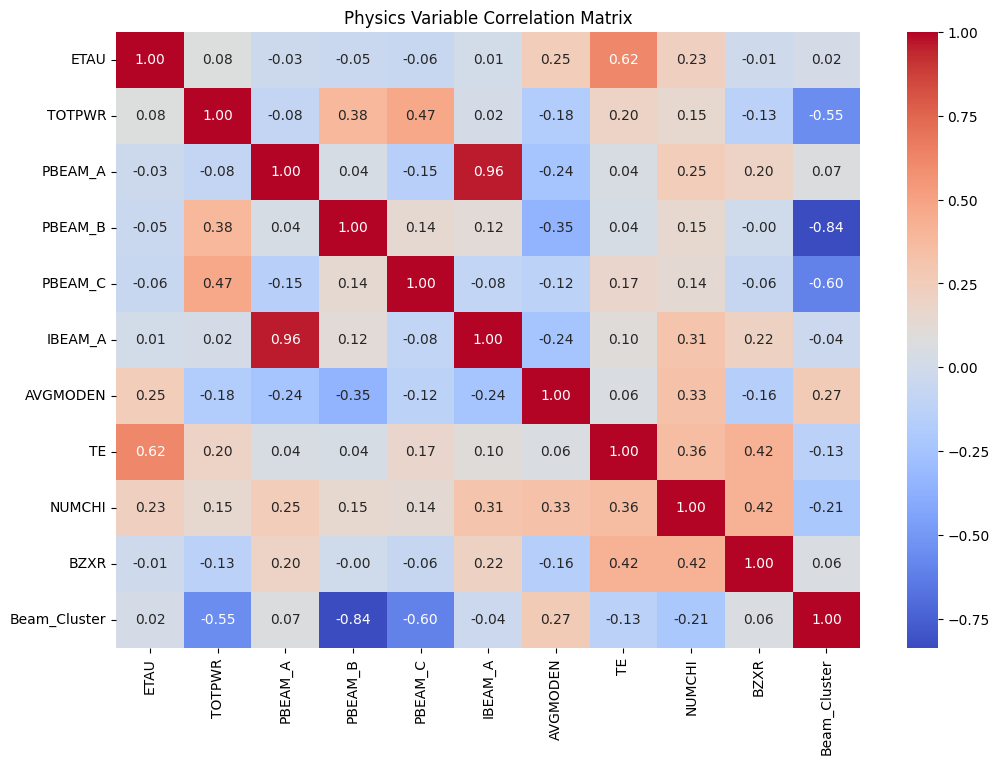

In [ ]:
def clean_idl_var(arr):
    arr = np.asanyarray(arr)
    if arr.dtype.byteorder not in ('=', '|'):
        arr = arr.byteswap().view(arr.dtype.newbyteorder('='))
    return arr.flatten().astype(np.float64)

path = r'/Users/aldensantoso/Desktop/OMFIT/data downloaded from ncrocker/APRIL21.SAV'

data = readsav(path, python_dict=True)
mp_data = data['mp'][0]
tr_data = data['tr'][0]

y_raw = clean_idl_var(tr_data['ETAU'])
y_clean = y_raw[y_raw > 0]

print(f"Original y_raw min: {y_raw.min()}")
print(f"Cleaned y_clean min: {y_clean.min()}")
print(f"Count after filtering: {len(y_clean)}")
plt.figure(figsize=(12, 8))
sns.heatmap(df_4mw.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Physics Variable Correlation Matrix")
plt.show()

In [ ]:
# Assuming 'mp' is your structure
bzxr_raw = clean_idl_var(mp_struct['BZXR'])

# Convert from Tesla*cm to Tesla at the magnetic axis (approx 100cm for NSTX-U)
bt_field = bzxr_raw / 100.0 

print(f"B_T Range: {bt_field.min():.2f} to {bt_field.max():.2f} Tesla")

B_T Range: 0.00 to 0.47 Tesla


--- Feature Ablation (AIC Evaluation) ---
Baseline features ['TE', 'TOTPWR', 'NEUTT'] | AIC: -3704.21
Added 'AVGMODEN' | AIC: -3702.21
Added 'IBEAM_A' | AIC: -3702.20
Added 'NUMCHI' | AIC: -3716.73

--- Bayesian Clustering ---


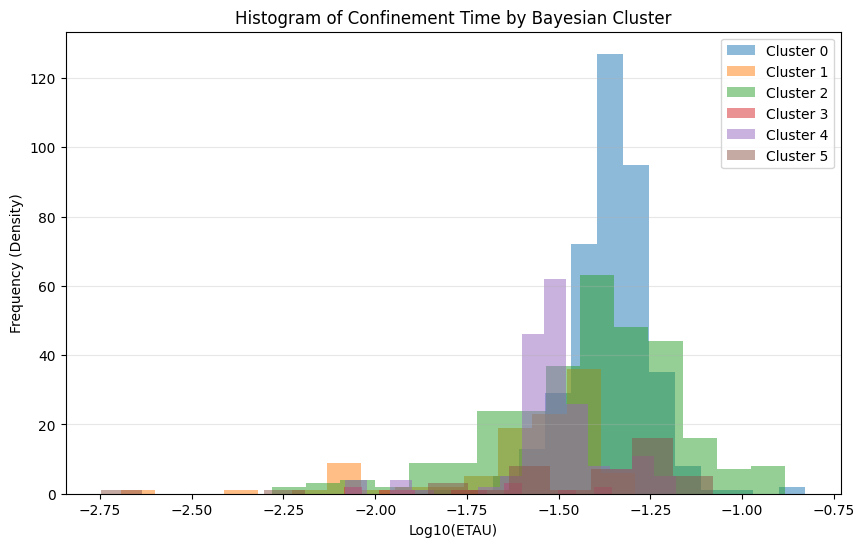

                            TE        TOTPWR  AVGMODEN      ETAU
Cluster_Posterior                                               
0                   957.764232  2.716423e-11 -2.196360  0.045286
1                   705.624670  1.917567e-11 -2.966357  0.028523
2                   904.364674  1.655556e-11 -0.392587  0.044158
3                     0.000000  0.000000e+00  0.000000  0.022190
4                   830.505668  2.598629e-11 -4.433943  0.032417
5                  1096.762583  1.784915e-11 -5.104208  0.045001


In [ ]:
# --- 0. REBUILD df_clean WITH ALL FEATURES ---
# Define the exact variables we want to pull from the IDL structure
base_features = ['TE', 'TOTPWR', 'NEUTT']
test_features = ['AVGMODEN', 'IBEAM_A', 'NUMCHI']
target_name = 'ETAU'

# Assuming mp_struct, tr_struct, and clean_idl_var are already loaded in your notebook
data_dict = {}
for name in base_features + test_features:
    data_dict[name] = clean_idl_var(mp_struct[name])
    
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

# Create the full DataFrame and filter out negative/zero ETAU values
df_full = pd.DataFrame(data_dict)
df_clean = df_full[df_full[target_name] > 0].copy()


# --- 1. FEATURE ABLATION & AIC ---
def calculate_aic(n, mse, num_params):
    return n * np.log(mse) + 2 * num_params

print("--- Feature Ablation (AIC Evaluation) ---")
X_base = df_clean[base_features].values
y_true = np.log10(df_clean['ETAU']).values

lr = LinearRegression().fit(X_base, y_true)
mse_base = mean_squared_error(y_true, lr.predict(X_base))
aic_base = calculate_aic(len(y_true), mse_base, len(base_features))
print(f"Baseline features {base_features} | AIC: {aic_base:.2f}")

for feat in test_features:
    current_feats = base_features + [feat]
    X_curr = df_clean[current_feats].values
    lr.fit(X_curr, y_true)
    mse_curr = mean_squared_error(y_true, lr.predict(X_curr))
    aic_curr = calculate_aic(len(y_true), mse_curr, len(current_feats))
    print(f"Added '{feat}' | AIC: {aic_curr:.2f}")


# --- 2. BAYESIAN CLUSTERING ---
print("\n--- Bayesian Clustering ---")
bgm = BayesianGaussianMixture(n_components=6, covariance_type='full', max_iter=500, random_state=42)

# Cluster based on core variables
cluster_features = df_clean[['TE', 'TOTPWR', 'AVGMODEN']].fillna(0)
cluster_labels = bgm.fit_predict(cluster_features)
df_clean['Cluster_Posterior'] = cluster_labels


# --- 3. HISTOGRAM VISUALIZATION ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for cluster in np.unique(cluster_labels):
    subset = df_clean[df_clean['Cluster_Posterior'] == cluster]['ETAU']
    if len(subset) > 5:
        plt.hist(np.log10(subset), bins=15, alpha=0.5, label=f'Cluster {cluster}')

plt.title('Histogram of Confinement Time by Bayesian Cluster')
plt.xlabel('Log10(ETAU)')
plt.ylabel('Frequency (Density)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Group the data by the new cluster labels and calculate the mean for each parameter
cluster_summary = df_clean.groupby('Cluster_Posterior')[['TE', 'TOTPWR', 'AVGMODEN', 'ETAU']].mean()

# Display the summary table
print(cluster_summary)

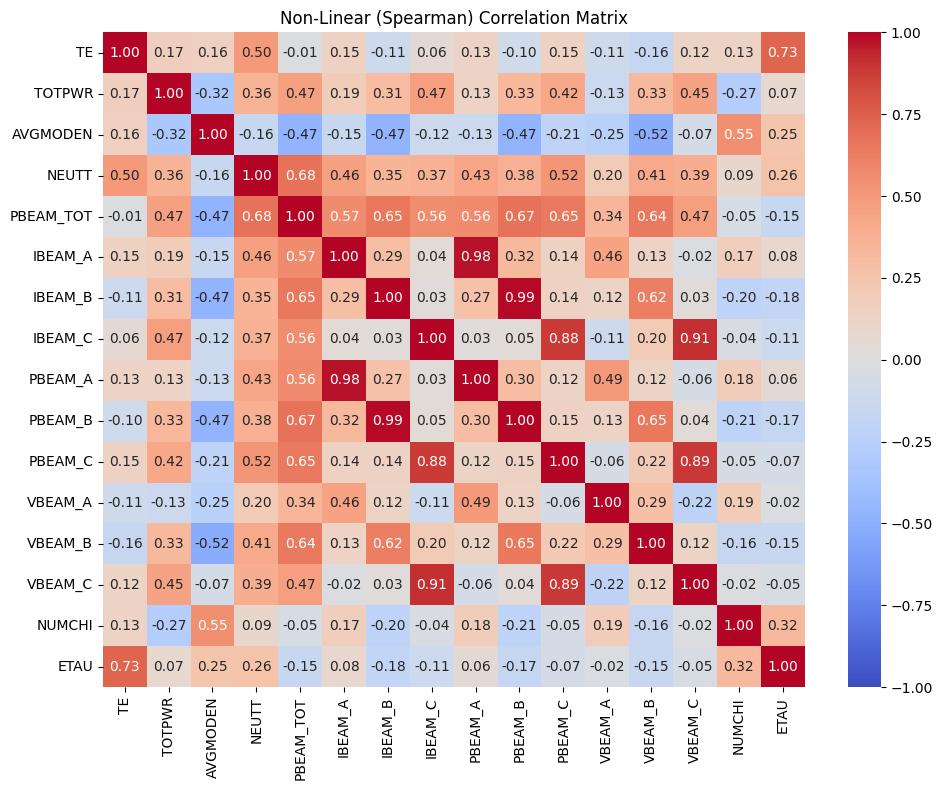


Baseline Model R^2: 0.946

Feature Importances (Impact on R^2):
      Feature  Importance (R2 Drop)
0          TE              1.103198
4   PBEAM_TOT              0.138504
3       NEUTT              0.131326
14     NUMCHI              0.100403
2    AVGMODEN              0.090712
11    VBEAM_A              0.042239
10    PBEAM_C              0.031931
7     IBEAM_C              0.022585
9     PBEAM_B              0.021957
8     PBEAM_A              0.016403
5     IBEAM_A              0.014605
13    VBEAM_C              0.014008
12    VBEAM_B              0.011289
6     IBEAM_B              0.011135
1      TOTPWR              0.000000

Trimming complete. Moving forward with: ['TE', 'PBEAM_TOT', 'NEUTT', 'NUMCHI', 'AVGMODEN', 'VBEAM_A', 'PBEAM_C', 'IBEAM_C', 'PBEAM_B', 'PBEAM_A', 'IBEAM_A', 'VBEAM_C', 'VBEAM_B', 'IBEAM_B']

Bayesian algorithm identified 10 active physical states.


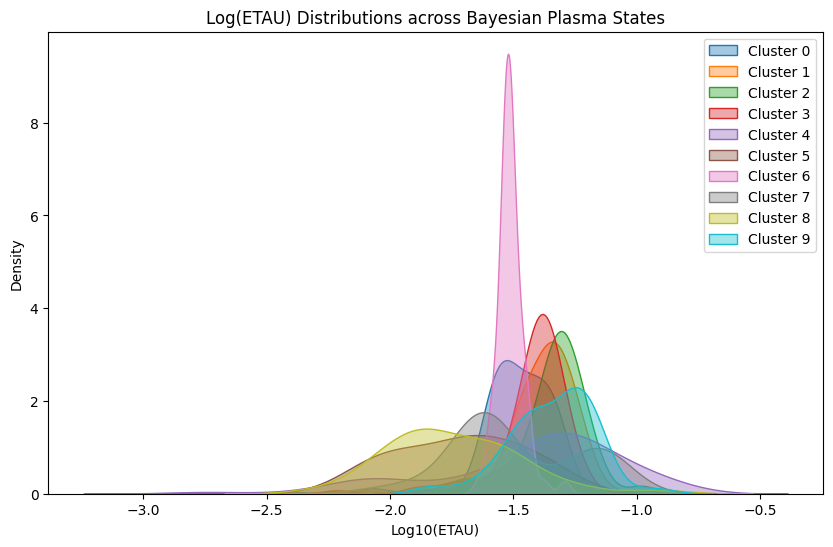


--- Average Feature Values per Cluster ---


,TE,PBEAM_TOT,NEUTT,NUMCHI,AVGMODEN,VBEAM_A,PBEAM_C,IBEAM_C,PBEAM_B,PBEAM_A,IBEAM_A,VBEAM_C,VBEAM_B,IBEAM_B,log10_ETAU
Bayesian_Cluster,,,,,,,,,,,,,,,
0,876.738131,5.969922,1.910030e+14,142995.733906,-3.245216,90.101728,1.995607,45.172400,2.017099,1.957216,44.368212,90.287384,90.618296,45.647602,-1.491016
1,885.480857,3.949785,1.294235e+14,141188.044828,-2.512829,90.075375,0.000662,0.119362,2.007035,1.942089,44.029855,-0.034764,90.325441,45.456251,-1.379242
2,986.165255,3.873752,1.248583e+14,141200.457364,-1.540945,-0.049624,1.907435,43.308284,1.966722,-0.000405,14.286433,89.800432,89.279473,44.656715,-1.335023
3,919.288574,4.897202,1.738601e+14,153084.651163,-1.508081,90.099775,0.993990,25.834729,1.930932,1.972280,44.704552,58.413147,87.473969,44.213107,-1.416802
4,930.963800,2.033193,7.436003e+13,144750.692308,-1.145120,90.045104,0.005934,0.081502,0.080738,1.946522,44.131331,0.235615,3.705084,1.918852,-1.435117
5,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.717307
6,806.451124,5.049902,1.126890e+14,136462.015873,-4.388172,89.680520,1.043397,28.480298,2.044272,1.962233,44.479965,66.639916,89.978792,46.405151,-1.512590
7,787.072251,1.933418,4.451188e+13,148795.945946,-0.407619,-0.052525,0.026419,0.667312,1.907240,-0.000241,9.000993,1.897297,88.152334,43.567267,-1.489012
8,866.138951,0.912515,2.308194e+13,104932.578947,-2.840027,20.600722,0.389729,10.554605,0.092107,0.430678,9.907105,24.667302,6.733421,2.955000,-1.740889


In [ ]:
# ---------------------------------------------------------
# STEP 1: START BIG (Load and Clean Data)
# ---------------------------------------------------------
all_features = ['TE', 'TOTPWR', 'AVGMODEN', 'NEUTT', 'PBEAM_TOT', 'IBEAM_A', 
                'IBEAM_B', 'IBEAM_C', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 
                'VBEAM_A', 'VBEAM_B', 'VBEAM_C', 'NUMCHI']
target = 'ETAU'

# Assuming mp_struct, tr_struct, and clean_idl_var are already loaded in memory
data_dict = {name: clean_idl_var(mp_struct[name]) for name in all_features}
data_dict[target] = clean_idl_var(tr_struct[target])

df_full = pd.DataFrame(data_dict)

# Strict quality-control sweep
df_full = df_full[(df_full[target] > 0) & (df_full[target].notna())].dropna()

# Pre-calculate log10(ETAU) for profiling later
df_full['log10_ETAU'] = np.log10(df_full[target])

# ---------------------------------------------------------
# STEP 2: NON-LINEAR CORRELATION MATRIX
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
# Calculate Spearman correlation including the target
corr_matrix = df_full[all_features + [target]].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Non-Linear (Spearman) Correlation Matrix")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# STEP 3: TIE TO R^2 AND TRIM VARIABLES (Feature Selection)
# ---------------------------------------------------------
X = df_full[all_features]
y = df_full[target]

# Train the baseline model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
baseline_r2 = r2_score(y, rf.predict(X))
print(f"\nBaseline Model R^2: {baseline_r2:.3f}")

# Scramble test to find real importance
perm_importance = permutation_importance(rf, X, y, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance (R2 Drop)': perm_importance.importances_mean
}).sort_values(by='Importance (R2 Drop)', ascending=False)

print("\nFeature Importances (Impact on R^2):")
print(importance_df)

# Trim variables that don't meaningfully drop the R^2 score
trimmed_features = importance_df[importance_df['Importance (R2 Drop)'] > 0.01]['Feature'].tolist()
print(f"\nTrimming complete. Moving forward with: {trimmed_features}")

# ---------------------------------------------------------
# STEP 4: BAYESIAN CLUSTERING (With Strict Penalty)
# ---------------------------------------------------------
X_trimmed = df_full[trimmed_features]

# Scale the data so power doesn't overwhelm density
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_trimmed)

# Bayesian Model with strict penalty (0.001) to prevent over-splitting
bgm = BayesianGaussianMixture(
    n_components=10, 
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=0.001, 
    max_iter=1000,
    random_state=42
)

# Assign clusters
cluster_labels = bgm.fit_predict(X_scaled)
df_full['Bayesian_Cluster'] = cluster_labels

# Count active states
active_clusters = [i for i, w in enumerate(bgm.weights_) if w > 0.01]
print(f"\nBayesian algorithm identified {len(active_clusters)} active physical states.")

# ---------------------------------------------------------
# STEP 5: VISUALIZE CONFINEMENT DISTRIBUTION
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
for cluster in active_clusters:
    # Use the pre-calculated log10_ETAU column
    subset = df_full[df_full['Bayesian_Cluster'] == cluster]['log10_ETAU']
    sns.kdeplot(subset, label=f'Cluster {cluster}', fill=True, alpha=0.4)

plt.title('Log(ETAU) Distributions across Bayesian Plasma States')
plt.xlabel('Log10(ETAU)')
plt.ylabel('Density')
plt.legend()
plt.show()

# ---------------------------------------------------------
# STEP 6: PHYSICAL PROFILES OF EACH CLUSTER
# ---------------------------------------------------------
# Group by the clusters and calculate the mean for the survivors + log10_ETAU
cluster_profiles = df_full.groupby('Bayesian_Cluster')[trimmed_features + ['log10_ETAU']].mean()

print("\n--- Average Feature Values per Cluster ---")
# Using standard display to avoid Jinja2 styling errors
display(cluster_profiles)

--- Conditions within each Sub-Cluster ---
             AVGMODEN                   NUMCHI              
                 mean       std           mean           std
Sub_Cluster                                                 
0           -0.010092  0.015434  134513.666667  45206.700635
1           -1.580755  0.979096  141583.952000   9192.328852
2           -0.427096  0.285546  148109.205882   4477.817649
3           -0.810355       NaN  142170.000000           NaN
4           -0.227015  0.246924  130816.250000  12105.119533
5           -3.252605  1.229262  140493.939516  18560.210639
6           -2.484626  1.448777  141402.006711  23635.159876
7           -3.079573  1.600127  143851.949153  11972.418443
8           -0.790024  0.842461  154760.222222  18564.923483
9           -1.187065  0.446731  153264.571429   3657.703982
10          -0.322353  0.371137  157197.937500   6166.277392
11          -1.225413  2.146077  143182.076923  26418.489536
12          -0.811448  1.881959   58072.96

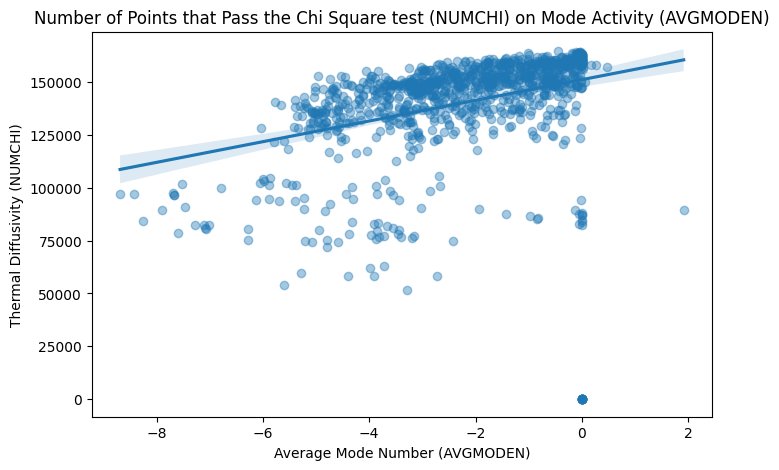


Actual Pearson Correlation (AVGMODEN vs NUMCHI): 0.3260

--- Shuffle Test Results ---
Shuffled Correlation Mean: 0.00087
Shuffled Correlation Std Dev: 0.03040


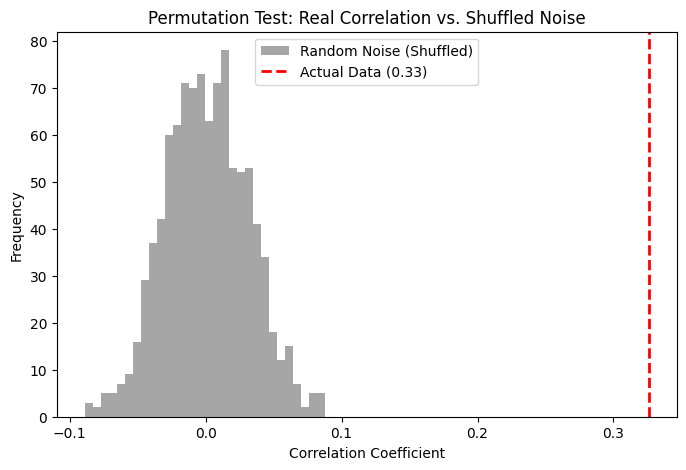

In [ ]:
# ---------------------------------------------------------
# 1. Simplify Data & Filter Variables
# ---------------------------------------------------------
# Remove unnecessary variables to clean up the correlation matrix
# Feel free to add/remove variables relevant to the Stutman paper
core_vars = ['VBEAM_A', 'VBEAM_B', 'VBEAM_C', 'AVGMODEN', 'NUMCHI', 'TOTPWR']

# Apply your clean_idl_var function to EACH variable individually 
# and store them in a dictionary
cleaned_columns = {}
for var in core_vars:
    # mp_struct[var] extracts just that one column to be cleaned
    cleaned_columns[var] = clean_idl_var(mp_struct[var])

# Convert the dictionary of clean columns into our DataFrame
df_exp = pd.DataFrame(cleaned_columns).dropna().copy()

# ---------------------------------------------------------
# 2. Main Clustering based on VBeamA, B, C Only
# ---------------------------------------------------------
# FIX 1: Corrected VBEAMC to VBEAM_C
beam_cols = ['VBEAM_A', 'VBEAM_B', 'VBEAM_C']
X_beams = df_exp[beam_cols]

# We standard-scale the beams. If you want to experiment with "weights"
# (e.g., if VBeamA has a stronger physical effect), you could multiply 
# the scaled VBEAMA column by a weight factor like 1.5 here.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_beams)

# Experimenting with 3 main clusters (e.g., Low, Med, High beam mixes)
kmeans_main = KMeans(n_clusters=3, random_state=42, n_init=10)
df_exp['Main_Cluster'] = kmeans_main.fit_predict(X_scaled)

# ---------------------------------------------------------
# 3. Break into Smaller Clusters & Measure Conditions
# ---------------------------------------------------------
df_exp['Sub_Cluster'] = -1
sub_cluster_id = 0

for cluster in sorted(df_exp['Main_Cluster'].unique()):
    # Isolate data for this main cluster
    subset_idx = df_exp[df_exp['Main_Cluster'] == cluster].index
    X_sub = df_exp.loc[subset_idx, beam_cols]
    
    # Break into  smaller clusters (Experiment with n_clusters!)
    if len(X_sub) > 10: 
        kmeans_sub = KMeans(n_clusters=5, random_state=42, n_init=30)
        sub_labels = kmeans_sub.fit_predict(scaler.transform(X_sub))
        
        for sub_l in np.unique(sub_labels):
            df_exp.loc[subset_idx[sub_labels == sub_l], 'Sub_Cluster'] = sub_cluster_id
            sub_cluster_id += 1

# Measure conditions within each sub-cluster
cluster_summary = df_exp.groupby('Sub_Cluster')[['AVGMODEN', 'NUMCHI']].agg(['mean', 'std'])
print("--- Conditions within each Sub-Cluster ---")
print(cluster_summary)

# ---------------------------------------------------------
# 4. Correlation between AVGMODEN and NUMCHI
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.regplot(data=df_exp, x='AVGMODEN', y='NUMCHI', scatter_kws={'alpha':0.4})
plt.title("Number of Points that Pass the Chi Square test (NUMCHI) on Mode Activity (AVGMODEN)")
plt.xlabel("Average Mode Number (AVGMODEN)")
plt.ylabel("Thermal Diffusivity (NUMCHI)")
plt.savefig("numchi_avgmoden_correlation.png")
plt.show()

actual_corr = df_exp['AVGMODEN'].corr(df_exp['NUMCHI'])
print(f"\nActual Pearson Correlation (AVGMODEN vs NUMCHI): {actual_corr:.4f}")

# ---------------------------------------------------------
# 5. Pandas Shuffle Method (Permutation Testing)
# ---------------------------------------------------------
# We shuffle AVGMODEN repeatedly to see what the correlation matrix 
# looks like when the physical relationship is completely broken.

n_iterations = 1000
shuffled_corrs = []

# Extract arrays for faster looping
numchi_vals = df_exp['NUMCHI'].values

for _ in range(n_iterations):
    # Pandas shuffle method (frac=1)
    shuffled_moden = df_exp['AVGMODEN'].sample(frac=1).values
    
    # Calculate the correlation of the broken relationship
    corr = np.corrcoef(shuffled_moden, numchi_vals)[0, 1]
    shuffled_corrs.append(corr)

shuffled_corrs = np.array(shuffled_corrs)
print(f"\n--- Shuffle Test Results ---")
print(f"Shuffled Correlation Mean: {shuffled_corrs.mean():.5f}")
print(f"Shuffled Correlation Std Dev: {shuffled_corrs.std():.5f}")

# Plot the noise vs reality
plt.figure(figsize=(8, 5))
plt.hist(shuffled_corrs, bins=30, alpha=0.7, color='gray', label='Random Noise (Shuffled)')
plt.axvline(actual_corr, color='red', linestyle='dashed', linewidth=2, label=f'Actual Data ({actual_corr:.2f})')
plt.title("Permutation Test: Real Correlation vs. Shuffled Noise")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("shuffle_test.png")
plt.show()

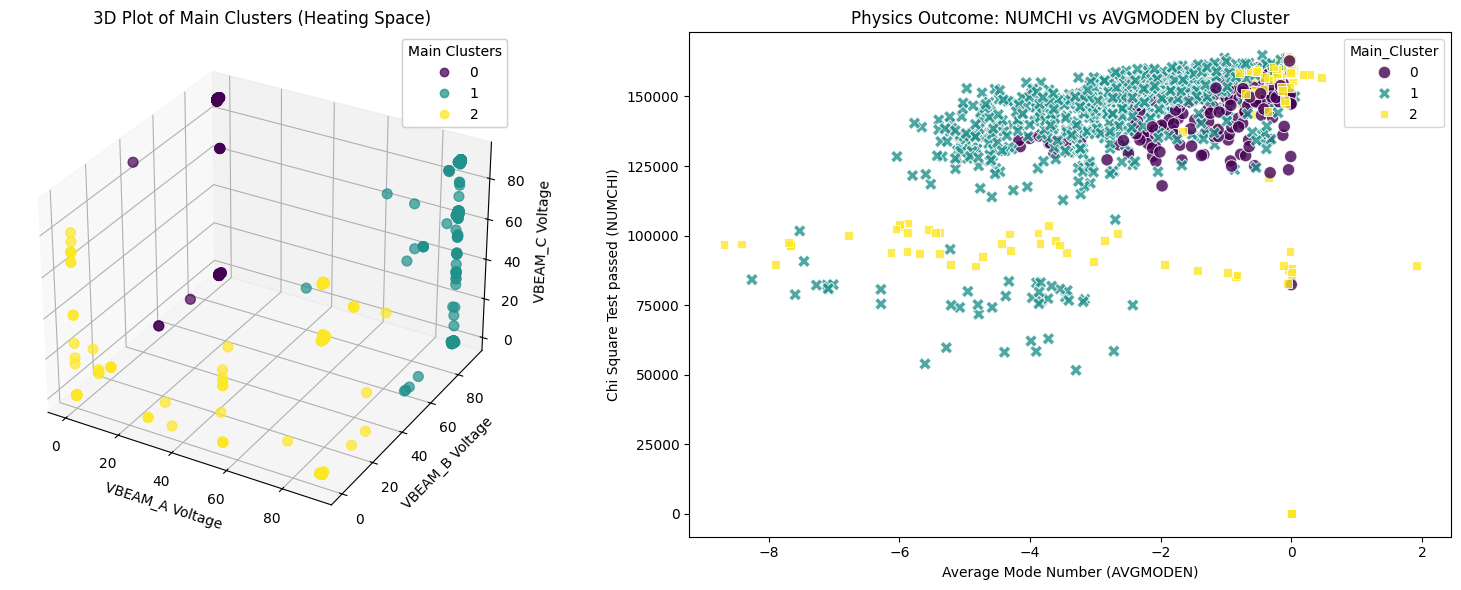

In [ ]:
# Set up the figure layout (1 row, 2 columns)
fig = plt.figure(figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: 3D Scatter of the Main Clusters (Heating Space)
# ---------------------------------------------------------
ax1 = fig.add_subplot(121, projection='3d')

# Create a 3D scatter plot colored by 'Main_Cluster'
scatter = ax1.scatter(df_exp['VBEAM_A'], df_exp['VBEAM_B'], df_exp['VBEAM_C'], 
                      c=df_exp['Main_Cluster'], cmap='viridis', s=50, alpha=0.7)

ax1.set_title("3D Plot of Main Clusters (Heating Space)")
ax1.set_xlabel('VBEAM_A Voltage')
ax1.set_ylabel('VBEAM_B Voltage')
ax1.set_zlabel('VBEAM_C Voltage')

# Add a legend
legend1 = ax1.legend(*scatter.legend_elements(), title="Main Clusters")
ax1.add_artist(legend1)

# ---------------------------------------------------------
# Plot 2: Physics Outcome Colored by Clusters
# ---------------------------------------------------------
ax2 = fig.add_subplot(122)



# Scatter plot of NUMCHI vs AVGMODEN, colored by cluster
sns.scatterplot(data=df_exp, x='AVGMODEN', y='NUMCHI', 
                hue='Main_Cluster', palette='viridis', style='Main_Cluster', 
                s=80, alpha=0.8, ax=ax2)

ax2.set_title("Physics Outcome: NUMCHI vs AVGMODEN by Cluster")
ax2.set_xlabel('Average Mode Number (AVGMODEN)')
ax2.set_ylabel('Chi Square Test passed (NUMCHI)')

plt.tight_layout()
plt.savefig("cluster_visualizations.png")
plt.show()

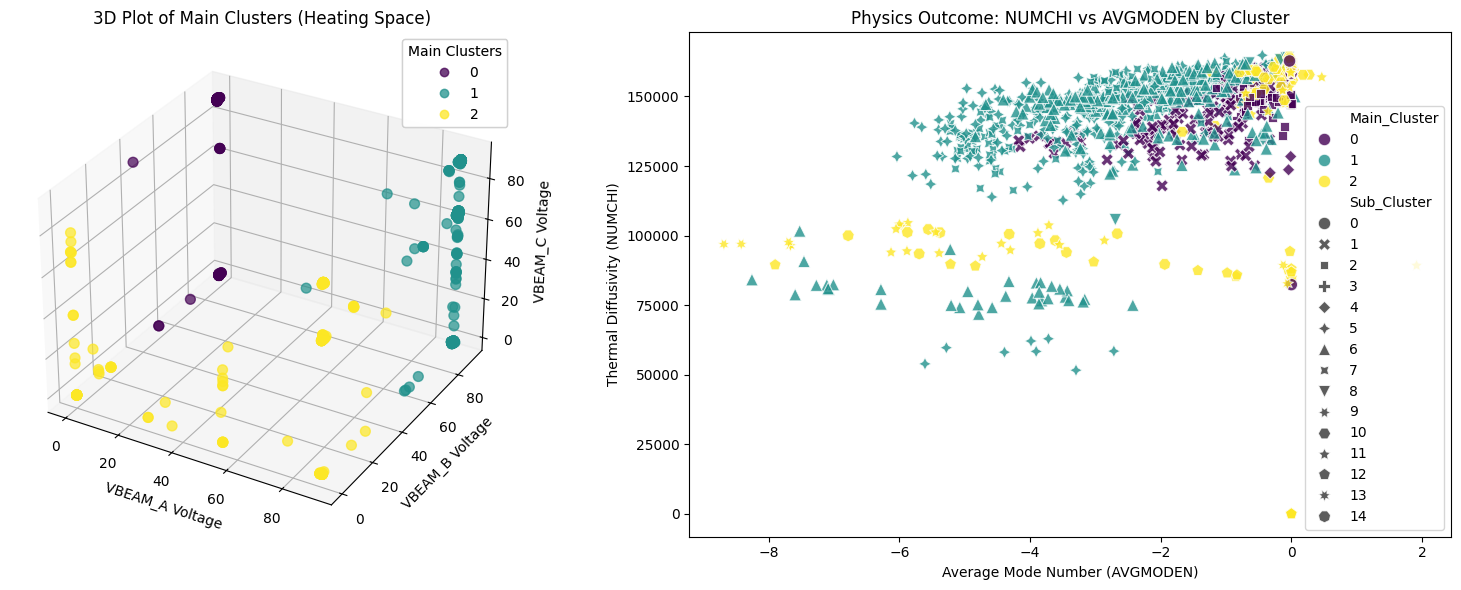

In [ ]:
# Set up the figure layout (1 row, 2 columns)
fig = plt.figure(figsize=(16, 6))

# ---------------------------------------------------------
# Plot 1: 3D Scatter of the Main Clusters (Heating Space)
# ---------------------------------------------------------
ax1 = fig.add_subplot(121, projection='3d')

# Create a 3D scatter plot colored by 'Main_Cluster'
scatter = ax1.scatter(df_exp['VBEAM_A'], df_exp['VBEAM_B'], df_exp['VBEAM_C'], 
                      c=df_exp['Main_Cluster'], cmap='viridis', s=50, alpha=0.7)

ax1.set_title("3D Plot of Main Clusters (Heating Space)")
ax1.set_xlabel('VBEAM_A Voltage')
ax1.set_ylabel('VBEAM_B Voltage')
ax1.set_zlabel('VBEAM_C Voltage')

# Add a legend
legend1 = ax1.legend(*scatter.legend_elements(), title="Main Clusters")
ax1.add_artist(legend1)

# ---------------------------------------------------------
# Plot 2: Physics Outcome Colored by Clusters
# ---------------------------------------------------------
ax2 = fig.add_subplot(122)



# Scatter plot of NUMCHI vs AVGMODEN, colored by cluster
sns.scatterplot(data=df_exp, x='AVGMODEN', y='NUMCHI', 
                hue='Main_Cluster', palette='viridis', style='Sub_Cluster', 
                s=80, alpha=0.8, ax=ax2)

ax2.set_title("Physics Outcome: NUMCHI vs AVGMODEN by Cluster")
ax2.set_xlabel('Average Mode Number (AVGMODEN)')
ax2.set_ylabel('Thermal Diffusivity (NUMCHI)')

plt.tight_layout()
plt.savefig("cluster_visualizations.png")
plt.show()

--- Raw Correlation Matrix ---


,VBEAM_A,VBEAM_B,VBEAM_C,AVGMODEN,NUMCHI,TOTPWR,Main_Cluster,Sub_Cluster
VBEAM_A,1.000000,0.030509,-0.140986,-0.248156,0.235080,-0.059106,0.529574,0.540281
VBEAM_B,0.030509,1.000000,0.131782,-0.327641,0.153547,0.384721,-0.778662,-0.746364
VBEAM_C,-0.140986,0.131782,1.000000,-0.126068,0.128160,0.445201,-0.234976,-0.467210
AVGMODEN,-0.248156,-0.327641,-0.126068,1.000000,0.325953,-0.193514,0.057544,0.129997
NUMCHI,0.235080,0.153547,0.128160,0.325953,1.000000,0.063242,-0.132121,-0.055694
TOTPWR,-0.059106,0.384721,0.445201,-0.193514,0.063242,1.000000,-0.385231,-0.446737
Main_Cluster,0.529574,-0.778662,-0.234976,0.057544,-0.132121,-0.385231,1.000000,0.942910
Sub_Cluster,0.540281,-0.746364,-0.467210,0.129997,-0.055694,-0.446737,0.942910,1.000000


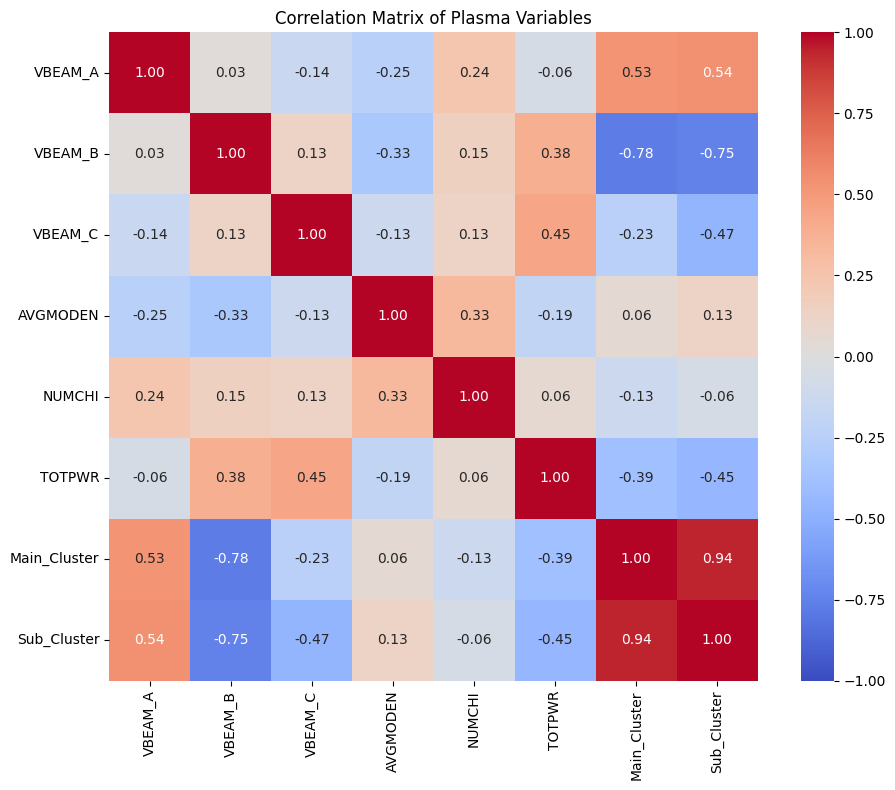

In [ ]:
# ---------------------------------------------------------
# 6. Full Correlation Matrix
# ---------------------------------------------------------
# Calculate the Pearson correlation matrix for the dataframe
corr_matrix = df_exp.corr()

# Print the raw numerical table
print("--- Raw Correlation Matrix ---")
display(corr_matrix)

# Plot a visual heatmap
plt.figure(figsize=(10, 8))
# annot=True prints the numbers inside the boxes
# cmap='coolwarm' makes positive correlations red and negative ones blue
# vmin=-1, vmax=1 sets the scale bounds exactly to the limits of correlation
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)

plt.title("Correlation Matrix of Plasma Variables")
plt.tight_layout()
plt.savefig("correlation_matrix_heatmap.png")
plt.show()

In [ ]:
# 1. Calculate the standard deviation of the original, unshuffled column
original_std = df_exp['AVGMODEN'].std()

# 2. Shuffle the column just like we did in the loop
shuffled_moden = df_exp['AVGMODEN'].sample(frac=1, random_state=42).values

# 3. Calculate the standard deviation of the newly shuffled array
# (We use np.std because shuffled_moden is now a numpy array, not a pandas series)
shuffled_std = np.std(shuffled_moden, ddof=1) 

print(f"Original AVGMODEN Std Dev: {original_std:.4f}")
print(f"Shuffled AVGMODEN Std Dev: {shuffled_std:.4f}")

Original AVGMODEN Std Dev: 1.7240
Shuffled AVGMODEN Std Dev: 1.7240


In [ ]:
# ---------------------------------------------------------
# Define the Main Clusters (The Beam Recipes)
# ---------------------------------------------------------
# Calculate the average voltage of each beam for each of the 3 Main Clusters
cluster_definitions = df_exp.groupby('Main_Cluster')[['VBEAM_A', 'VBEAM_B', 'VBEAM_C']].mean()

print("--- What Defines Each Main Cluster (Average Voltages) ---")
display(cluster_definitions)

# Optional: Look at how the total power varies across these clusters
power_summary = df_exp.groupby('Main_Cluster')['TOTPWR'].mean()
print("\n--- Average Total Power (TOTPWR) per Cluster ---")
print(power_summary)

--- What Defines Each Main Cluster (Average Voltages) ---


,VBEAM_A,VBEAM_B,VBEAM_C
Main_Cluster,,,
0,-0.050463,88.795275,69.786711
1,90.001937,89.774867,45.363746
2,70.072314,1.949003,35.966028



--- Average Total Power (TOTPWR) per Cluster ---
Main_Cluster
0    3.045400e-11
1    2.425115e-11
2    1.032216e-11
Name: TOTPWR, dtype: float64


In [ ]:
# --- 0. DATA PREPARATION ---
# Rebuild df_clean to ensure ALL required columns ('TE', 'NEUTT', etc.) are present.
# This assumes mp_struct, tr_struct, and clean_idl_var() are already loaded in your notebook memory.

required_mp_features = ['TE', 'TOTPWR', 'NEUTT', 'AVGMODEN', 'NUMCHI']
target_name = 'ETAU'

data_dict = {}
# Extract predictors
for name in required_mp_features:
    data_dict[name] = clean_idl_var(mp_struct[name])
    
# Extract target
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

# Create DataFrame and filter for valid (positive) ETAU values
df_full = pd.DataFrame(data_dict)
df_clean = df_full[df_full[target_name] > 0].copy()

# Ensure all column names are uppercase to prevent KeyErrors
df_clean.columns = df_clean.columns.str.upper()


# --- 1. Define our target and baseline features ---
target = np.log10(df_clean['ETAU']).values
base_features = ['TE', 'TOTPWR', 'NEUTT']

# --- 2. Define the different combinations of mode properties to test ---
mode_tests = {
    'Baseline (No Mode Properties)': [],
    'Baseline + AVGMODEN': ['AVGMODEN'],
    'Baseline + NUMCHI': ['NUMCHI'],
    'Baseline + AVGMODEN + NUMCHI': ['AVGMODEN', 'NUMCHI']
}

# --- 3. Initialize the Random Forest ---
# We use a fixed random_state so the results are perfectly reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("--- Random Forest R^2 Ablation Test ---")
print("Target: Log10(ETAU)\n")

# --- 4. Loop through the test cases, add/subtract features, and evaluate ---
results = {}
for test_name, extra_features in mode_tests.items():
    # Combine base features with the specific mode properties for this test
    current_features = base_features + extra_features
    
    # Extract the data
    X = df_clean[current_features].values
    
    # Run 5-Fold Cross Validation for R^2
    # This trains the model 5 times on different chunks of data to ensure stability
    r2_scores = cross_val_score(rf_model, X, target, cv=5, scoring='r2')
    
    # Calculate the mean and standard deviation of the R^2 scores
    mean_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    results[test_name] = mean_r2
    
    print(f"{test_name}")
    print(f"Features used: {current_features}")
    print(f"Average R^2: {mean_r2:.4f} (+/- {std_r2:.4f})\n")

# --- 5. Calculate the absolute improvement over the baseline ---
baseline_r2 = results['Baseline (No Mode Properties)']
print("--- Improvement Summary ---")
for test_name, r2 in results.items():
    if test_name != 'Baseline (No Mode Properties)':
        diff = r2 - baseline_r2
        print(f"{test_name}: {'+' if diff > 0 else ''}{diff:.4f} R^2")

--- Random Forest R^2 Ablation Test ---
Target: Log10(ETAU)

Baseline (No Mode Properties)
Features used: ['TE', 'TOTPWR', 'NEUTT']
Average R^2: -0.1722 (+/- 0.4148)

Baseline + AVGMODEN
Features used: ['TE', 'TOTPWR', 'NEUTT', 'AVGMODEN']
Average R^2: 0.0942 (+/- 0.1705)

Baseline + NUMCHI
Features used: ['TE', 'TOTPWR', 'NEUTT', 'NUMCHI']
Average R^2: -0.6513 (+/- 1.2873)

Baseline + AVGMODEN + NUMCHI
Features used: ['TE', 'TOTPWR', 'NEUTT', 'AVGMODEN', 'NUMCHI']
Average R^2: -0.2142 (+/- 0.8600)

--- Improvement Summary ---
Baseline + AVGMODEN: +0.2664 R^2
Baseline + NUMCHI: -0.4791 R^2
Baseline + AVGMODEN + NUMCHI: -0.0420 R^2


In [ ]:
# --- 0. DATA PREPARATION & OUTLIER FILTERING ---
required_mp_features = ['TE', 'TOTPWR', 'NEUTT', 'AVGMODEN', 'NUMCHI']
target_name = 'ETAU'

# Build the DataFrame
data_dict = {}
for name in required_mp_features:
    data_dict[name] = clean_idl_var(mp_struct[name])
    
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

df_full = pd.DataFrame(data_dict)
df_full.columns = df_full.columns.str.upper()

# Basic valid data filter (No negative/zero time)
df_clean = df_full[df_full['ETAU'] > 0].copy()

# OUTLIER FILTER: Remove the top 1% and bottom 1% to prevent extreme noise from breaking the model
lower_bound = df_clean['ETAU'].quantile(0.01)
upper_bound = df_clean['ETAU'].quantile(0.99)
df_clean = df_clean[(df_clean['ETAU'] >= lower_bound) & (df_clean['ETAU'] <= upper_bound)]

print(f"Data ready. Filtered out {(len(df_full) - len(df_clean))} invalid/outlier shots.")


# --- 1. FEATURES & TARGET ---
target = np.log10(df_clean['ETAU']).values
base_features = ['TE', 'TOTPWR', 'NEUTT']

mode_tests = {
    'Baseline (No Mode Properties)': [],
    'Baseline + AVGMODEN': ['AVGMODEN'],
    'Baseline + NUMCHI': ['NUMCHI'],
    'Baseline + AVGMODEN + NUMCHI': ['AVGMODEN', 'NUMCHI']
}


# --- 2. INITIALIZE THE MODEL & KFOLD SHUFFLER ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# KFOLD SHUFFLER: This ensures the data is randomly mixed before being split into 5 chunks
# It prevents chronological sorting issues where one chunk is entirely different from another.
shuffled_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- Random Forest R^2 Ablation Test (with Shuffling) ---")
print("Target: Log10(ETAU)\n")


# --- 3. EVALUATION LOOP ---
results = {}
for test_name, extra_features in mode_tests.items():
    current_features = base_features + extra_features
    X = df_clean[current_features].values
    
    # Run Cross Validation using the SHUFFLED KFold
    r2_scores = cross_val_score(rf_model, X, target, cv=shuffled_kfold, scoring='r2')
    
    mean_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    results[test_name] = mean_r2
    
    print(f"{test_name}")
    print(f"Features used: {current_features}")
    print(f"Average R^2: {mean_r2:.4f} (+/- {std_r2:.4f})\n")


# --- 4. SUMMARY ---
baseline_r2 = results['Baseline (No Mode Properties)']
print("--- Improvement Summary ---")
for test_name, r2 in results.items():
    if test_name != 'Baseline (No Mode Properties)':
        diff = r2 - baseline_r2
        print(f"{test_name}: {'+' if diff > 0 else ''}{diff:.4f} R^2")

Data ready. Filtered out 40 invalid/outlier shots.

--- Random Forest R^2 Ablation Test (with Shuffling) ---
Target: Log10(ETAU)

Baseline (No Mode Properties)
Features used: ['TE', 'TOTPWR', 'NEUTT']
Average R^2: 0.5738 (+/- 0.0489)

Baseline + AVGMODEN
Features used: ['TE', 'TOTPWR', 'NEUTT', 'AVGMODEN']
Average R^2: 0.6487 (+/- 0.0394)

Baseline + NUMCHI
Features used: ['TE', 'TOTPWR', 'NEUTT', 'NUMCHI']
Average R^2: 0.6718 (+/- 0.0504)

Baseline + AVGMODEN + NUMCHI
Features used: ['TE', 'TOTPWR', 'NEUTT', 'AVGMODEN', 'NUMCHI']
Average R^2: 0.6805 (+/- 0.0460)

--- Improvement Summary ---
Baseline + AVGMODEN: +0.0749 R^2
Baseline + NUMCHI: +0.0980 R^2
Baseline + AVGMODEN + NUMCHI: +0.1067 R^2


In [ ]:
# --- 0. DATA PREPARATION & OUTLIER FILTERING ---
all_required_features = [
    'TE', 'TOTPWR', 'NEUTT', 'AVGMODEN', 'NUMCHI',
    'PBEAM_TOT', 'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 
    'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 
    'VBEAM_A', 'VBEAM_B', 'VBEAM_C'
]
target_name = 'ETAU'

# Build the DataFrame from the IDL structure
data_dict = {}
for name in all_required_features:
    data_dict[name] = clean_idl_var(mp_struct[name])
    
data_dict[target_name] = clean_idl_var(tr_struct[target_name])

df_full = pd.DataFrame(data_dict)
df_full.columns = df_full.columns.str.upper()

# Basic valid data filter (No negative/zero time)
df_clean = df_full[df_full['ETAU'] > 0].copy()

# OUTLIER FILTER: Remove the top 1% and bottom 1% to prevent extreme noise
lower_bound = df_clean['ETAU'].quantile(0.01)
upper_bound = df_clean['ETAU'].quantile(0.99)
df_clean = df_clean[(df_clean['ETAU'] >= lower_bound) & (df_clean['ETAU'] <= upper_bound)]

print(f"Data ready. Extracted {len(all_required_features)} features.")
print(f"Filtered out {(len(df_full) - len(df_clean))} invalid/outlier shots.\n")


# --- 1. FEATURES & TARGET ---
target = np.log10(df_clean['ETAU']).values

# The pure baseline
core_baseline = ['TE', 'TOTPWR', 'NEUTT']

# The list of all new variables to test individually
individual_vars = [
    'AVGMODEN', 'NUMCHI', 'PBEAM_TOT', 
    'IBEAM_A', 'IBEAM_B', 'IBEAM_C', 
    'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 
    'VBEAM_A', 'VBEAM_B', 'VBEAM_C'
]

# Programmatically build the test dictionary
mode_tests = {
    'Baseline (Core Only)': []
}

# Add each variable individually
for var in individual_vars:
    mode_tests[f'Baseline + {var}'] = [var]

# Combine them all at the end
mode_tests['Baseline + ALL VARIABLES COMBINED'] = individual_vars


# --- 2. INITIALIZE THE MODEL & KFOLD SHUFFLER ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
shuffled_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("--- Random Forest R^2 Ablation Test ---")
print("Target: Log10(ETAU)\n")


# --- 3. EVALUATION LOOP ---
results = {}
for test_name, extra_features in mode_tests.items():
    current_features = core_baseline + extra_features
    X = df_clean[current_features].values
    
    # Run Cross Validation
    r2_scores = cross_val_score(rf_model, X, target, cv=shuffled_kfold, scoring='r2')
    
    mean_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    results[test_name] = mean_r2


# --- 4. ISOLATED IMPROVEMENT SUMMARY ---
baseline_r2 = results['Baseline (Core Only)']

print("=========================================")
print(f"BASELINE R^2 (Core Only): {baseline_r2:.4f}")
print("=========================================\n")

print("--- INDIVIDUAL VARIABLE CONTRIBUTIONS ---")
# Sort the individual results so the most helpful variables appear at the top
individual_results = {k: v for k, v in results.items() if k not in ['Baseline (Core Only)', 'Baseline + ALL VARIABLES COMBINED']}
sorted_individuals = sorted(individual_results.items(), key=lambda item: item[1], reverse=True)

for test_name, r2 in sorted_individuals:
    diff = r2 - baseline_r2
    var_name = test_name.replace('Baseline + ', '')
    print(f"  {var_name.ljust(15)}: {'+' if diff > 0 else ''}{diff:.4f} R^2")

print("\n--- COMBINED CONTRIBUTION ---")
all_r2 = results['Baseline + ALL VARIABLES COMBINED']
diff_all = all_r2 - baseline_r2
print(f"  ALL 15 VARIABLES COMBINED: {'+' if diff_all > 0 else ''}{diff_all:.4f} R^2")
print("=========================================")

Data ready. Extracted 15 features.
Filtered out 40 invalid/outlier shots.

--- Random Forest R^2 Ablation Test ---
Target: Log10(ETAU)

BASELINE R^2 (Core Only): 0.5738

--- INDIVIDUAL VARIABLE CONTRIBUTIONS ---
  NUMCHI         : +0.0980 R^2
  PBEAM_TOT      : +0.0828 R^2
  PBEAM_C        : +0.0774 R^2
  IBEAM_B        : +0.0754 R^2
  AVGMODEN       : +0.0749 R^2
  PBEAM_B        : +0.0722 R^2
  IBEAM_A        : +0.0691 R^2
  VBEAM_C        : +0.0679 R^2
  PBEAM_A        : +0.0618 R^2
  VBEAM_B        : +0.0612 R^2
  IBEAM_C        : +0.0551 R^2
  VBEAM_A        : +0.0518 R^2

--- COMBINED CONTRIBUTION ---
  ALL 15 VARIABLES COMBINED: +0.1516 R^2


In [ ]:
# in the other notebook
mp_df.to_csv("mp_df.csv")

In [ ]:
# ALL CODE THAT CUTS ENTRIES (CLEANING DATA)
# (cell #VSC-44af3913)
df = pd.DataFrame({
    'avgmodef': clean_idl_var(mp_data['AVGMODEF']),
    'totpwr':   clean_idl_var(mp_data['TOTPWR']),
    'etau':     clean_idl_var(tr_data['ETAU'])
})

# 4. Data Filtering
# Removing non-physical negative values for energy confinement time
df_clean = df[df['etau'] > 0].copy()
# ...existing code...

# (cell #VSC-513494ec)
# Create a mask to remove non-positive confinement times
mask = etau_full > 0
etau_clean = etau_full[mask]
# ... later used as x_data_clean = x_data_full[mask] in plotting ...

# (cell #VSC-7e7501d7)
y_raw = clean_idl_var(tr_data['ETAU'])
y_clean = y_raw[y_raw > 0]
# ...existing code...

# (cell #VSC-268149d8 / #VSC-d26f3...) - feature extraction using master_mask
etau_raw = clean_idl_var(tr_struct['ETAU'])
master_mask = etau_raw > 0

features_dict = {
    'ETAU': etau_raw[master_mask],
    'TOTPWR': clean_idl_var(mp_struct['TOTPWR'])[master_mask],
    'PBEAM_A': clean_idl_var(mp_struct['PBEAM_A'])[master_mask],
    'PBEAM_B': clean_idl_var(mp_struct['PBEAM_B'])[master_mask],
    'PBEAM_C': clean_idl_var(mp_struct['PBEAM_C'])[master_mask],
    'IBEAM_A': clean_idl_var(mp_struct['IBEAM_A'])[master_mask],
    'AVGMODEN': clean_idl_var(mp_struct['AVGMODEN'])[master_mask],
    'TE': clean_idl_var(mp_struct['TE'])[master_mask],
    'NUMCHI': clean_idl_var(mp_struct['NUMCHI'])[master_mask],
    'BZXR' : clean_idl_var(mp_struct['BZXR'])[master_mask]
}

df = pd.DataFrame(features_dict)

max_p = df['TOTPWR'].max()
p_min, p_max = (3.8e6, 4.2e6) if max_p > 1e6 else (0, 2)
df_4mw = df[(df['TOTPWR'] >= p_min) & (df['TOTPWR'] <= p_max)].copy()
# ...existing code...

# (cell #VSC-7e7501d7 diagnostic)
y_raw = clean_idl_var(tr_data['ETAU'])
y_clean = y_raw[y_raw > 0]
# ...existing code...

# (cell #VSC-e90d4487)
df_full = pd.DataFrame(data_dict)

# Strict quality-control sweep
df_full = df_full[(df_full[target] > 0) & (df_full[target].notna())].dropna()

df_full['log10_ETAU'] = np.log10(df_full[target])
# ...existing code...

# (cell #VSC-f92689d8)
df_full = pd.DataFrame(data_dict)
df_full.columns = df_full.columns.str.upper()

# Basic valid data filter (No negative/zero time)
df_clean = df_full[df_full['ETAU'] > 0].copy()

# OUTLIER FILTER: Remove the top 1% and bottom 1% to prevent extreme noise from breaking the model
lower_bound = df_clean['ETAU'].quantile(0.01)
upper_bound = df_clean['ETAU'].quantile(0.99)
df_clean = df_clean[(df_clean['ETAU'] >= lower_bound) & (df_clean['ETAU'] <= upper_bound)]

print(f"Data ready. Filtered out {(len(df_full) - len(df_clean))} invalid/outlier shots.")
# ...existing code...

# (cell #VSC-00f2e4f4)
df_full = pd.DataFrame(data_dict)
df_full.columns = df_full.columns.str.upper()

# Basic valid data filter (No negative/zero time)
df_clean = df_full[df_full['ETAU'] > 0].copy()

# OUTLIER FILTER: Remove the top 1% and bottom 1% to prevent extreme noise
lower_bound = df_clean['ETAU'].quantile(0.01)
upper_bound = df_clean['ETAU'].quantile(0.99)
df_clean = df_clean[(df_clean['ETAU'] >= lower_bound) & (df_clean['ETAU'] <= upper_bound)]
# ...existing code...

# (cell #VSC-35575357)
y_raw = clean_idl_var(tr_data['ETAU'])
y_clean = y_raw[y_raw > 0]

# (multiple plotting cells)
# usages of mask / master_mask and slicing such as:
# x_data_clean = x_data_full[mask]
# a_clean = clean_idl_var(mp_struct['IBEAM_A'])[master_mask]
# b_clean = clean_idl_var(mp_struct['IBEAM_B'])[master_mask]
# c_clean = clean_idl_var(mp_struct['IBEAM_C'])[master_mask]
# etau_clean = etau_raw[master_mask]
# ...existing code...
```# filepath: /Users/aldensantoso/Documents/plasma_research/ML Project/plasma_project.ipynb
# ...existing code...
# (cell #VSC-44af3913)
df = pd.DataFrame({
    'avgmodef': clean_idl_var(mp_data['AVGMODEF']),
    'totpwr':   clean_idl_var(mp_data['TOTPWR']),
    'etau':     clean_idl_var(tr_data['ETAU'])
})

# 4. Data Filtering
# Removing non-physical negative values for energy confinement time
df_clean = df[df['etau'] > 0].copy()
# ...existing code...

# (cell #VSC-513494ec)
# Create a mask to remove non-positive confinement times
mask = etau_full > 0
etau_clean = etau_full[mask]
# ... later used as x_data_clean = x_data_full[mask] in plotting ...

# (cell #VSC-7e7501d7)
y_raw = clean_idl_var(tr_data['ETAU'])
y_clean = y_raw[y_raw > 0]
# ...existing code...

# (cell #VSC-268149d8 / #VSC-d26f3...) - feature extraction using master_mask
etau_raw = clean_idl_var(tr_struct['ETAU'])
master_mask = etau_raw > 0

features_dict = {
    'ETAU': etau_raw[master_mask],
    'TOTPWR': clean_idl_var(mp_struct['TOTPWR'])[master_mask],
    'PBEAM_A': clean_idl_var(mp_struct['PBEAM_A'])[master_mask],
    'PBEAM_B': clean_idl_var(mp_struct['PBEAM_B'])[master_mask],
    'PBEAM_C': clean_idl_var(mp_struct['PBEAM_C'])[master_mask],
    'IBEAM_A': clean_idl_var(mp_struct['IBEAM_A'])[master_mask],
    'AVGMODEN': clean_idl_var(mp_struct['AVGMODEN'])[master_mask],
    'TE': clean_idl_var(mp_struct['TE'])[master_mask],
    'NUMCHI': clean_idl_var(mp_struct['NUMCHI'])[master_mask],
    'BZXR' : clean_idl_var(mp_struct['BZXR'])[master_mask]
}

df = pd.DataFrame(features_dict)

max_p = df['TOTPWR'].max()
p_min, p_max = (3.8e6, 4.2e6) if max_p > 1e6 else (0, 2)
df_4mw = df[(df['TOTPWR'] >= p_min) & (df['TOTPWR'] <= p_max)].copy()
# ...existing code...

# (cell #VSC-7e7501d7 diagnostic)
y_raw = clean_idl_var(tr_data['ETAU'])
y_clean = y_raw[y_raw > 0]
# ...existing code...

# (cell #VSC-e90d4487)
df_full = pd.DataFrame(data_dict)

# Strict quality-control sweep
df_full = df_full[(df_full[target] > 0) & (df_full[target].notna())].dropna()

df_full['log10_ETAU'] = np.log10(df_full[target])
# ...existing code...

# (cell #VSC-f92689d8)
df_full = pd.DataFrame(data_dict)
df_full.columns = df_full.columns.str.upper()

# Basic valid data filter (No negative/zero time)
df_clean = df_full[df_full['ETAU'] > 0].copy()

# OUTLIER FILTER: Remove the top 1% and bottom 1% to prevent extreme noise from breaking the model
lower_bound = df_clean['ETAU'].quantile(0.01)
upper_bound = df_clean['ETAU'].quantile(0.99)
df_clean = df_clean[(df_clean['ETAU'] >= lower_bound) & (df_clean['ETAU'] <= upper_bound)]

print(f"Data ready. Filtered out {(len(df_full) - len(df_clean))} invalid/outlier shots.")
# ...existing code...

# (cell #VSC-00f2e4f4)
df_full = pd.DataFrame(data_dict)
df_full.columns = df_full.columns.str.upper()

# Basic valid data filter (No negative/zero time)
df_clean = df_full[df_full['ETAU'] > 0].copy()

# OUTLIER FILTER: Remove the top 1% and bottom 1% to prevent extreme noise
lower_bound = df_clean['ETAU'].quantile(0.01)
upper_bound = df_clean['ETAU'].quantile(0.99)
df_clean = df_clean[(df_clean['ETAU'] >= lower_bound) & (df_clean['ETAU'] <= upper_bound)]
# ...existing code...

# (cell #VSC-35575357)
y_raw = clean_idl_var(tr_data['ETAU'])
y_clean = y_raw[y_raw > 0]

# (multiple plotting cells)
# usages of mask / master_mask and slicing such as:
# x_data_clean = x_data_full[mask]
# a_clean = clean_idl_var(mp_struct['IBEAM_A'])[master_mask]
# b_clean = clean_idl_var(mp_struct['IBEAM_B'])[master_mask]
# c_clean = clean_idl_var(mp_struct['IBEAM_C'])[master_mask]
# etau_clean = etau_raw[master_mask]
# ...existing code...